## Figure 9-13 (parameter exploration) from formation channel paper 

below is the code that reproduces the 2D parameter exploration (simulation silos) exploration 


In [5]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


from typing import Optional  # change Optional[str] to str | None when using higher versions of python3

%matplotlib inline

In [15]:
## data path - change this 
path_to_github_folder = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/"
path_to_plotting_folder = path_to_github_folder + "plottingCode/"
path_to_file_folder =  "fc_data/Data_formation_channels_intrinsic/"
path_to_file = path_to_github_folder + path_to_file_folder
path_to_default_scripts = path_to_plotting_folder
path_to_save_fig = path_to_github_folder + "figures/"
path_interactive_fig  = path_to_github_folder + "interactive_figures_and_tables/"

sys.path.append(path_to_plotting_folder +'.')
from default_scripts import *  # imports standard functions for formatting and for dictionary of colors used

# Figures formation-channel parameter exploration
### and extra/appendix figures (BNS variations, absolute rate, interactive plots) 

This notebook reproduces the parameter-exploration figures for the isolated-binary formation-channel comparison paper. It generates the main static figures, interactive HTML versions, with-CE versus without-CE rate panels, and an auxiliary parameter-family summary plot.

## Data requirements

Download the latest version of the data from Zenodo:

https://doi.org/10.5281/zenodo.7815201

Use the latest version associated with the DOI, not necessarily the first archived version.

The notebook expects the data directory to contain:

```
Data_formation_channels_intrinsic/
├── BH-BH_rates_review.csv
├── BH-NS_rates_review.csv
├── NS-NS_rates_review.csv
├── BH-BH_fcRelations.csv
├── BH-NS_fcRelations.csv
├── NS-NS_fcRelations.csv
├── simulation_specs.csv
└── extra_fc_rates/
    ├── vanSon2023_sfrd.csv
    ├── Broekgaarden_BHBH_all_SFRD_variations_combined.csv
    ├── Broekgaarden_BHNS_all_SFRD_variations_combined.csv
    └── Broekgaarden_NSNS_all_SFRD_variations_combined.csv
    
```


The `*_rates_review.csv` files provide the formation-channel fractions and total local intrinsic merger rates for each model.

The `*_fcRelations.csv` files define model-to-model parameter variations through the columns: `legend, from_modelname, to_modelname, using, travel_label, from_option, to_option`

The `simulation_specs.csv` file provides metadata used for labels, hover text, annotations, and code names. Important columns include: `model, code, label_1, label_2, label_3, label_4`

### Instructions & Things to change before running 

for this code to work you will need the files as outlined above  
 you can find this in the Zenodo file or on GitHub inside the Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/ folder 
  - it imports some functions from the `common_code` file above, but you dont need this :) (just uncomment if needed) 
  - Update the path variables to point to your local data and output folders:
  - Create the output directory if it does not already exist: `os.makedirs("Output_Figures", exist_ok=True)`
  

# Main Functions in this Notebook

This notebook contains a set of plotting and utility functions used to explore the diversity of isolated binary evolution formation channels across population-synthesis studies.

The main figures focus on:

- the fraction of systems forming with and without common-envelope (CE) evolution,
- total local intrinsic merger rates,
- parameter-variation relationships,
- and study-to-study differences across BBH, BHNS, and BNS populations.

---

## Core Utility Functions

### `obtain_fc_dict()`

Defines the formation-channel metadata used throughout the notebook.

This includes:

- formation-channel labels,
- colors,
- hatches,
- axis labels,
- plotting labels,
- and merger-rate metadata.

This function is imported from the default_code scripts 

---

### `normalize_study_label(label)`

Utility function used to normalize study names before assigning colors.

Removes whitespace inconsistencies so that studies with identical names receive the same color across BBH, BHNS, and BNS figures.

---

### `build_global_study_color_map(...)`

Builds one global color dictionary shared across all DCO populations.

This ensures that studies such as:

```text
Shao and Li (2021)
van Son (2023)
Broekgaarden et al. (2022)
```
retain the same color


# Main Static Figure Functions

## `plot_withoutCE_all_and_by_study(...)`

Main static plotting function used to generate the without-CE formation-channel figures.

This function creates:

1. A large combined panel showing all studies together.
2. A subplot grid with one panel per study.

The plotted quantities are:

fraction without CE  vs  total local intrinsic merger rate or absolute without-CE merger rate  vs  total local intrinsic merger rate







# BBHs, BHNS, and BNS; with SFRD model variations 




In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import math
from matplotlib.ticker import AutoMinorLocator
import re
%matplotlib inline




mpl.rcParams['hatch.linewidth'] = 0.5   # default is 1.0
mpl.rcParams['hatch.color'] = 'darkslategray'   # optional: set hatch color




def normalize_study_label(label):
    return str(label).strip()


def build_global_study_color_map(
    path_to_file,
    dco_labels=("BH-BH", "BH-NS", "NS-NS"),
    cmap_name="husl",
):
    """
    Build one consistent color map across all DCO relation files.
    Same study label gets same color for BBH/BHNS/BNS.
    """
    all_studies = []

    for dco in dco_labels:
        relation_file = f"{dco}_fcRelations.csv"
        rel_path = os.path.join(path_to_file, relation_file)

        if not os.path.exists(rel_path):
            continue

        df_rel = pd.read_csv(rel_path)

        if "legend" not in df_rel.columns:
            continue

        studies = df_rel["legend"].dropna().map(normalize_study_label).unique()
        all_studies.extend(studies)

    all_studies = sorted(set(all_studies))

    if cmap_name.lower() == "husl":
        palette = sns.color_palette("husl", len(all_studies))
    else:
        cmap = plt.get_cmap(cmap_name)
        palette = [cmap(i / max(1, len(all_studies) - 1)) for i in range(len(all_studies))]

    return {study: palette[i] for i, study in enumerate(all_studies)}



def plot_withoutCE_all_and_by_study(
    path_to_file,
    DCOlabel="BH-BH",
    broek_sfrd_path=None,
    relation_file=None,
    marker="o",
    size=50,
    line_alpha=0.7,
    line_style="-",
    line_width=2.5,
    figsize_all=(8, 6),
    ncols_grid=5,
    figsize_grid_per_panel=(4.0, 3.2),  # (width, height) per subplot
    cmap_name="tab20",
    sharex=True,
    sharey=True,
    save_big_pdf=None,
    save_grid_pdf=None,
    dpi=300,
    x_quantity="fraction",   # "fraction" or "absolute_rate"
    xscale=None,             # optional override
    annotate_models=None,    # whether to annotate some model data points 
    study_color_map=None,    # use consistent color mapping for simulation sets? 
):
    """
    Make:
      (1) one big plot: fraction without CE vs total intrinsic rate for all studies
      (2) a subplot grid: same relation, one panel per study (legend)

    Returns
    -------
    fig_all, ax_all, fig_grid, axes_grid
    """
    
    
    
    if annotate_models is None:
        annotate_models = []
    annotate_models = set(annotate_models)
    
    
    
    def map_dco_label_for_broek_file(dco_label: str) -> str:
        """
        Map plotting labels like 'BH-BH' to file labels like 'BHBH'.
        """
        mapping = {
            "BH-BH": "BHBH",
            "BH-NS": "BHNS",
            "NS-NS": "NSNS",
            "BHBH": "BHBH",
            "BHNS": "BHNS",
            "NSNS": "NSNS",
        }
        if dco_label not in mapping:
            raise ValueError(f"Unsupported DCOlabel: {dco_label}")
        return mapping[dco_label]
    

    # --- Load relation file (pairs of models) ---
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # --- Load rates file (fractions + total rate per model) ---
    rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file))
    df_rates = df_rates.fillna(0.0).set_index("model")
    
    
    
    # --- Load simulation specs for code labels ---
    specs_path = os.path.join(path_to_file, "simulation_specs.csv")
    if os.path.exists(specs_path):
        df_specs = pd.read_csv(specs_path).fillna("")
    else:
        df_specs = pd.DataFrame()
        
        
    def get_label_1(modelname):
        if df_specs.empty:
            return ""

        model_col = "model" if "model" in df_specs.columns else "name"
        if model_col not in df_specs.columns or "label_1" not in df_specs.columns:
            return ""

        match = df_specs.loc[df_specs[model_col] == modelname, "label_1"]

        if len(match) == 0:
            return ""

        return str(match.iloc[0]).strip()    
    

    def get_code_label_for_study(df_sub):
        if df_specs.empty or "code" not in df_specs.columns:
            return ""

        model_col = "model" if "model" in df_specs.columns else "name"
        if model_col not in df_specs.columns:
            return ""

        models = set(df_sub["from_modelname"]).union(set(df_sub["to_modelname"]))
        codes = (
            df_specs.loc[df_specs[model_col].isin(models), "code"]
            .astype(str)
            .str.strip()
            .replace("", np.nan)
            .dropna()
            .unique()
        )

        return ", ".join(sorted(codes))
    
    

    # --- OPTIONAL: load van Son 2023 secondary SFRD variations ---
    vanson_sfrd_file = os.path.join(path_to_file, "extra_fc_rates", "vanSon2023_sfrd.csv")
    if os.path.exists(vanson_sfrd_file):
        df_rates_vanson_sfrd = pd.read_csv(vanson_sfrd_file).fillna(0.0).set_index("model")
    else:
        df_rates_vanson_sfrd = None
    
    # --- OPTIONAL: load Broekgaarden secondary SFRD/S(Z,z) variations ---
    broek_file_label = map_dco_label_for_broek_file(DCOlabel)

    if broek_sfrd_path is None:
        broek_sfrd_file = os.path.join(
            path_to_file,
            "extra_fc_rates",
            f"Broekgaarden_{broek_file_label}_all_SFRD_variations_combined.csv"
        )
    else:
        # allow either a direct file path OR a folder path
        if os.path.isdir(broek_sfrd_path):
            broek_sfrd_file = os.path.join(
                broek_sfrd_path,
                f"Broekgaarden_{broek_file_label}_all_SFRD_variations_combined.csv"
            )
        else:
            broek_sfrd_file = broek_sfrd_path

    print("Looking for Broekgaarden SFRD file at:", broek_sfrd_file)
    print("Exists?", os.path.exists(broek_sfrd_file))

    if os.path.exists(broek_sfrd_file):
        df_rates_broek_sfrd = pd.read_csv(broek_sfrd_file).fillna(0.0)
        print("Loaded Broekgaarden SFRD rows:", len(df_rates_broek_sfrd))
        print("Columns:", list(df_rates_broek_sfrd.columns))
    else:
        df_rates_broek_sfrd = None
        print("Broekgaarden SFRD file not loaded.")
        
        
        
        
        
    

    # --- Formation-channel metadata ---
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
    yname = fc_dict["total"]["axlabel"]             # y-axis label (rate)

    # x axis label for "fraction without common envelope"
    channels = fc_dict["CE_simple"]["channels"]
    channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")

    if x_quantity == "fraction":
        xname = channel_dict["axlabel"]
    elif x_quantity == "absolute_rate":
        xname = r"$\mathcal{R}_{\rm without\ CE}$ \  $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]"
    else:
        raise ValueError(f"Unsupported x_quantity: {x_quantity}")

    # --- Studies (legend groups) ---
    legends = list(df_rel["legend"].dropna().unique())
    legends_sorted = sorted(legends)

    # --- Color map ---
    if study_color_map is None:
        study_color_map = build_global_study_color_map(path_to_file, cmap_name=cmap_name)

    color_map = {
        leg: study_color_map.get(normalize_study_label(leg), "k")
        for leg in legends_sorted
    }

    # --- explicitly set van Son 2023 study + fiducial model ---
    vanSon_legend = "van Son (2023) "
    vanSon_fiducial_model = "van Son (2023) "
    # --- explicitly set Broekgaarden study label ---
    broek_legend = None
    for leg in legends_sorted:
        leg_clean = str(leg).strip().lower()
        if "broekgaarden" in leg_clean:
            broek_legend = leg
            break

    print("Using broek_legend =", repr(broek_legend))
    print("Using vanSon_legend =", repr(vanSon_legend))
    print("Using vanSon_fiducial_model =", repr(vanSon_fiducial_model))
    print("Using broek_legend =", repr(broek_legend))
    
    
    def get_x_from_main_df(df, model, x_quantity="fraction"):
        """
        Return x-value for a model from the main rates dataframe.
        """
        frac = float(df.loc[model, "fraction without common envelope"])
        total = float(df.loc[model, fc_total_header])

        if x_quantity == "fraction":
            return frac
        elif x_quantity == "absolute_rate":
            return frac * total
        else:
            raise ValueError(f"Unsupported x_quantity: {x_quantity}")

    def get_x_from_secondary_values(frac, total, x_quantity="fraction"):
        """
        Return x-value from already-extracted fraction/total values
        (useful for auxiliary SFRD files).
        """
        frac = float(frac)
        total = float(total)

        if x_quantity == "fraction":
            return frac
        elif x_quantity == "absolute_rate":
            return frac * total
        else:
            raise ValueError(f"Unsupported x_quantity: {x_quantity}")    

    # ------------- helper: plot a set of relations onto an axis -------------
    def plot_relations_on_ax(ax, df_rel_subset, legend_for_color=None):
        """
        Plot points for models and connect from->to for each row in df_rel_subset.
        If legend_for_color is None, color per row's legend.
        """
        for _, row in df_rel_subset.iterrows():
            leg = row["legend"]
            color = color_map[legend_for_color] if legend_for_color is not None else color_map.get(leg, "k")

            m_from = row["from_modelname"]
            m_to = row["to_modelname"]

            coords = {}
            for model in [m_from, m_to]:
                if model not in df_rates.index:
                    continue

                x = get_x_from_main_df(df_rates, model, x_quantity=x_quantity)
                y = float(df_rates.loc[model, fc_total_header])
                coords[model] = (x, y)

                ax.scatter(
                    x, y,
                    s=size,
                    c=[color],
                    marker=marker,
                    edgecolor="k",
                    linewidths=0.5,
                    zorder=10
                )

            if m_from in coords and m_to in coords:
                (x1, y1) = coords[m_from]
                (x2, y2) = coords[m_to]
                ax.plot(
                    [x1, x2], [y1, y2],
                    color=color,
                    linestyle=line_style,
                    linewidth=line_width,
                    alpha=line_alpha,
                    zorder=5
                )

    # ------------- helper: plot van Son 2023 secondary SFRD variations -------------
    def plot_vanSon2023_secondary_sfrd(ax, legend_for_color):
        """
        Add the secondary S(Z,z)/SFRD variations for van Son 2023:
        - same color as van Son 2023
        - behind the main relations
        - each extra point connected to the fiducial main-model point
        """
        if df_rates_vanson_sfrd is None:
            return
        if legend_for_color is None:
            return
        if vanSon_fiducial_model is None:
            return
        if vanSon_fiducial_model not in df_rates.index:
            return
        if legend_for_color != vanSon_legend:
            return

        color = color_map[legend_for_color]

        # fiducial point from the MAIN rates file
        x_fid = get_x_from_main_df(df_rates, vanSon_fiducial_model, x_quantity=x_quantity)
        y_fid = float(df_rates.loc[vanSon_fiducial_model, fc_total_header])

        # plot all extra points except any duplicate fiducial row in the extra csv
        for model in df_rates_vanson_sfrd.index:
            if "Fiducial" in str(model):
                continue

            frac = df_rates_vanson_sfrd.loc[model, "fraction without common envelope"]
            y = float(df_rates_vanson_sfrd.loc[model, fc_total_header])
            x = get_x_from_secondary_values(frac, y, x_quantity=x_quantity)

            # faint background line to fiducial
            ax.plot(
                [x_fid, x], [y_fid, y],
                color=color,
                linestyle="-",
                linewidth=line_width * 0.45,
                alpha=0.54,
                zorder=0
            )


            # faint background point
            ax.scatter(
                x, y,
                s=size * 0.28,
                c=[color],
                marker=marker,
                edgecolor="none",
                linewidths=0.0,
                alpha=0.18,
                zorder=1
            )
    
    
    
    # ------------- helper: plot Broekgaarden secondary SFRD variations -------------
    def plot_broekgaarden_secondary_sfrd(ax, legend_for_color):
        """
        Add the secondary S(Z,z)/SFRD variations for the Broekgaarden study:
        - same color as Broekgaarden study
        - behind the main relations
        - each extra point connected to the corresponding main-model point
          by matching model_name A/B/.../T to df_rates models like B22-A-fiducial
        """
        print("\n--- plot_broekgaarden_secondary_sfrd ---")
        print("legend_for_color =", repr(legend_for_color))
        print("broek_legend     =", repr(broek_legend))

        if df_rates_broek_sfrd is None:
            print("EXIT: df_rates_broek_sfrd is None")
            return
        if legend_for_color is None:
            print("EXIT: legend_for_color is None")
            return
        if broek_legend is None:
            print("EXIT: broek_legend is None")
            return
        if str(legend_for_color).strip() != str(broek_legend).strip():
            print("EXIT: legend mismatch")
            return
        if legend_for_color not in color_map:
            print("EXIT: legend_for_color not in color_map")
            return

        color = color_map[legend_for_color]

        # Build mapping letter -> main Broekgaarden fiducial model
        main_model_map = {}

        # First pass: explicitly prefer fiducial rows
        for letter in list("ABCDEFGHIJKLMNOPQRST"):
            fid_candidates = [
                str(model).strip()
                for model in df_rates.index
                if re.match(rf"^[A-Z0-9]+-{letter}-fiducial$", str(model).strip(), flags=re.IGNORECASE)
            ]
            if len(fid_candidates) > 0:
                main_model_map[letter] = fid_candidates[0]

        # Second pass: fallback to first B22-letter-* match if no fiducial exists
        for model in df_rates.index:
            model_str = str(model).strip()
            m = re.match(r"^[A-Z0-9]+-([A-T])-", model_str, flags=re.IGNORECASE)
            if m:
                letter = m.group(1).upper()
                if letter not in main_model_map:
                    main_model_map[letter] = model_str


        n_plotted = 0

        for _, row in df_rates_broek_sfrd.iterrows():
            letter = str(row["model_name"]).strip().upper()

            if letter not in main_model_map:
                continue

            main_model = main_model_map[letter]

            # Main point from BH-BH_rates_review.csv
            x_fid = get_x_from_main_df(df_rates, main_model, x_quantity=x_quantity)
            y_fid = float(df_rates.loc[main_model, fc_total_header])

            # Background S(Z,z) variation point
            frac = float(row["without_CE_fraction"])
            y = float(row["total_rate"])
            x = get_x_from_secondary_values(frac, y, x_quantity=x_quantity)

            if not np.isfinite(x) or not np.isfinite(y):
                continue
            if y <= 0:
                continue

            # faint background line
            ax.plot(
                [x_fid, x], [y_fid, y],
                color=color,
                linestyle="-",
                linewidth=line_width * 0.45,
                alpha=0.34,
                zorder=0
            )

            # faint background point
            ax.scatter(
                x, y,
                s=size * 0.28,
                c=[color],
                marker=marker,
                edgecolor="none",
                linewidths=0.0,
                alpha=0.18,
                zorder=1
            )

            n_plotted += 1

        print("Broekgaarden extra points plotted:", n_plotted)
    
    
    
    def annotate_selected_models(ax, df_rates, df_specs, annotate_models, df_sub=None):
        if not annotate_models:
            return

        model_col = "model"

        for model in annotate_models:

            # Only annotate in subpanels where this model appears in the relation table
            if df_sub is not None:
                models_in_panel = set(df_sub["from_modelname"]).union(set(df_sub["to_modelname"]))

                if model not in models_in_panel:
                    continue

            if model not in df_rates.index:
                print(f"Warning: {model} not found in rates table")
                continue

            if model not in set(df_specs[model_col]):
                print(f"Warning: {model} not found in specs table")
                continue

            x = get_x_from_main_df(df_rates, model, x_quantity=x_quantity)
            y = float(df_rates.loc[model, fc_total_header])

            label = df_specs.loc[df_specs[model_col] == model, "label_1"].iloc[0]
            
            if model in ["DT22-M11", "DT22-M6", "Boesky_alphaCE_0_1_beta0_75"]: # overwrite with second label that is more dominant 
                label = df_specs.loc[df_specs[model_col] == model, "label_2"].iloc[0]

            elif model in ["RG21-noBH-kick-SN:delayed", "RG21-ECSN:Full-SN:delayed", "Olejak21-M481 (changedCEcriteria+switch)", "RG21-SN:delayed", "RG21-noBHkick-SN:N20"]: # overwrite with both labels that are dominant 
                label_0 = df_specs.loc[df_specs[model_col] == model, "label_2"].iloc[0]
                label_1 = df_specs.loc[df_specs[model_col] == model, "label_1"].iloc[0]
                label = label_0 + '\n' + label_1
                
            elif model in ["Boesky_sigma_750_RMP_M", "Boesky_alphaCE_0_1_beta0_25", "Boesky_alphaCE_0_1_beta0_75"]:
                label_0 = df_specs.loc[df_specs[model_col] == model, "label_1"].iloc[0]
                label_1 = df_specs.loc[df_specs[model_col] == model, "label_2"].iloc[0]
                label_2 = df_specs.loc[df_specs[model_col] == model, "label_3"].iloc[0]
                label = label_0 + '\n' + label_1 +  '\n' + label_2

            xmin, xmax = -0.1, 1.05
            ymin, ymax = ax.get_ylim()
            
            # axes fraction not absolute 
            x_frac =  x #(x - xmin) / (xmax - xmin)

            if x_frac > 0.9:
                xytext = (-8, 8)
                ha = "center"
            elif x_frac < 0.15:
                xytext = (8, 8)
                ha = "center"
            elif (x_frac >= 0.15) & (x_frac < 0.35):
                xytext = (0, 12)
                ha = "center"      
            elif (x_frac >= 0.35) & (x_frac < 0.5):
                xytext = (8, 10)
                ha = "center"  
            elif (x_frac >= 0.5) & (x_frac <= 0.9):
                xytext = (12, 8)
                ha = "center"              


            ax.annotate(
                str(label),
                xy=(x, y),
                xytext=xytext,
                textcoords="offset points",
                fontsize=8,
                ha=ha,
                va="bottom",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8,
                ),
                zorder=30,
                clip_on=True,
            )
    
    
    
    # ===================== (1) BIG PLOT: all studies =====================
    fig_all, ax_all = plt.subplots(1, 1, figsize=figsize_all)

    plot_relations_on_ax(ax_all, df_rel)
    
    
    DCOaxLabel_dict = {"BH-BH": "BBH", "BH-NS": "BHNS", "NS-NS": "BNS"}

    ax_all.text(
        0.275, 0.97,
        DCOaxLabel_dict[DCOlabel],
        transform=ax_all.transAxes,
        ha="left",
        va="top",
        fontsize=28,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            alpha=0.8,
            edgecolor="none"
        ),
        zorder=50,
    )
    

    # axes styling
    layoutAxes(ax_all, nameX=xname, nameY=yname, fontsize=20)
    if xscale is None:
        xscale_use = "linear" if x_quantity == "fraction" else "log"
    else:
        xscale_use = xscale

    ax_all.set_xscale(xscale_use)
    ax_all.set_yscale("log")
    ax_all.grid(True, alpha=0.3)
    if x_quantity == "fraction":
        ax_all.set_xlim(0, 1)

    # legend (one handle per study)
    handles = []
    for leg in legends_sorted:
        handles.append(
            plt.Line2D([], [], color=color_map[leg], marker=marker, linestyle="",
                       markersize=2*np.sqrt(size)/2, markeredgecolor="k", label=leg)
        )
#     if DCOlabel=='NS-NS':ncol_lab=3
#     else: ncol_lab=2
        
    ax_all.legend(handles=handles, loc="best", frameon=False, ncol=2, fontsize=10)
        
    fig_all.tight_layout()
    
    

    # ===================== (2) GRID: one panel per study =====================
    n_studies = len(legends_sorted)
    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    fig_grid_w = figsize_grid_per_panel[0] * ncols
    fig_grid_h = figsize_grid_per_panel[1] * nrows
    fig_grid, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_grid_w, fig_grid_h),
        sharex=sharex,
        sharey=sharey
    )

    # Flatten axes robustly
    axes_flat = np.array(axes).reshape(-1)

    # --- style knobs (tweak to taste) ---
    tick_labelsize = 15
    tick_length_major = 8
    tick_length_minor = 4
    tick_width = 1.
    panel_labelsize = 14

    for i, leg in enumerate(legends_sorted):
        ax = axes_flat[i]
        df_sub = df_rel[df_rel["legend"] == leg]

        # plot this study
        plot_relations_on_ax(ax, df_sub, legend_for_color=leg)

        # add van Son 2023 secondary SFRD variations only in the van Son panel
        if str(leg).strip() == str(vanSon_legend).strip():
            plot_vanSon2023_secondary_sfrd(ax, vanSon_legend)
        
        # add Broekgaarden secondary SFRD variations only in the Broekgaarden panel
        if str(leg).strip() == str(broek_legend).strip():
            plot_broekgaarden_secondary_sfrd(ax, broek_legend)
        
        # scales/grid
        ax.set_xscale(xscale_use)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)

        # --- study name: top-left inside panel ---
        ax.text(
            0.98, 0.05, r'$\textbf{%s}$'%str(leg),
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.75,
                edgecolor="none"
            ),
            zorder=20
        )

        # --- code label: bottom-left inside panel ---
        code_label = get_code_label_for_study(df_sub)

        if code_label:
            ax.text(
                0.03, 0.05, code_label,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=9,
                fontweight="normal",
                color="0.25",
                bbox=dict(
                    boxstyle="round,pad=0.20",
                    facecolor="white",
                    alpha=0.65,
                    edgecolor="none"
                ),
                zorder=20
            )
        

        # --- ticks: bigger labels, shorter ticks, minor ticks on x ---
        ax.tick_params(
            axis="both", which="major",
            labelsize=tick_labelsize,
            length=tick_length_major,
            width=tick_width,
            direction="in"
        )
        ax.tick_params(
            axis="both", which="minor",
            labelsize=tick_labelsize,
            length=tick_length_minor,
            width=tick_width,
            direction="in"
        )

        # minor ticks on x-axis
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis="x", which="minor", bottom=True)
        

        # --- annotate selected outlier models ---
        annotate_selected_models(
            ax=ax,
            df_rates=df_rates,
            df_specs=df_specs,
            annotate_models=annotate_models,
            df_sub=df_sub
        )
        
        
        # ---------- soft background grid ----------
        ax.grid(
            True,
            which="major",
            linestyle="--",
            linewidth=0.6,
            alpha=0.26,
            zorder=0,
        )

        ax.grid(
            True,
            which="minor",
            linestyle=":",
            linewidth=0.4,
            alpha=0.14,
            zorder=0,
        )

        
        

    # Turn off unused axes
    for j in range(n_studies, len(axes_flat)):
        axes_flat[j].axis("off")

    label_fontsize = 20
    ylabel_pad = 15

    if sharex:
        fig_grid.supxlabel(
            r'$\textbf{%s}$'%xname,
            fontsize=label_fontsize,
            y=0.02
        )

    if sharey:
        fig_grid.supylabel(
            r'$\textbf{%s}$'%yname,
            fontsize=label_fontsize,
            x=0.01
        )

    # --- remove spacing between subpanels ---
    fig_grid.subplots_adjust(left=0.06, right=0.995, bottom=0.06, top=0.995,
                             wspace=0.0, hspace=0.0)

    fig_grid.tight_layout()
    
    
    # --- make big panel match grid/subpanel limits ---
    valid_axes = [ax for ax in axes_flat[:n_studies] if ax.has_data()]

    if len(valid_axes) > 0:
        common_xlim = valid_axes[0].get_xlim()
        common_ylim = valid_axes[0].get_ylim()

        ax_all.set_xlim(common_xlim)
        ax_all.set_ylim(common_ylim)
    

    # ===================== SAVE FIGURES =====================
    if save_big_pdf is not None:
        fig_all.savefig(
            save_big_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved big plot to: {save_big_pdf}")

    if save_grid_pdf is not None:
        fig_grid.savefig(
            save_grid_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved grid plot to: {save_grid_pdf}")

    return fig_all, ax_all, fig_grid, axes

import os



def make_withoutCE_plots(
    DCOlabel: str,
    data_path: str = "path/to/path",
    output_fig_path: str = "path/to/file",
    cmap_name: str = "husl",
    show: bool = True,
    ncols_grid=5,
    x_quantity="fraction",
    xscale=None,
    annotate_models=None
):
    """
    Wrapper to generate and save without-CE plots with consistent settings.
    """

    # ---------------- map label for filenames ----------------
    label_map = {
        "BH-BH": "BHBH",
        "BH-NS": "BHNS",
        "NS-NS": "NSNS",
        "BHBH": "BHBH",
        "BHNS": "BHNS",
        "NSNS": "NSNS",
    }

    if DCOlabel not in label_map:
        raise ValueError(f"Unsupported DCOlabel: {DCOlabel}")

    file_label = label_map[DCOlabel]

    # ---------------- paths ----------------

    # ensure output directory exists
    os.makedirs(path_to_save_fig, exist_ok=True)

    # Broekgaarden background file
    broek_dir = os.path.join(data_path, "extra_fc_rates")
    broek_file = os.path.join(
        broek_dir,
        f"Broekgaarden_{file_label}_all_SFRD_variations_combined.csv"
    )

    if not os.path.exists(broek_file):
        print(f"WARNING: Broekgaarden file not found:\n{broek_file}")
        broek_file = None

    # ---------------- output filenames ----------------
    save_big = os.path.join(
        path_to_save_fig,
        'Fig9+_' +  f"{file_label}_fraction_withoutCE_all.pdf"
    )

    save_grid = os.path.join(
        path_to_save_fig,
        'Fig9+_' + f"{file_label}_fraction_withoutCE_grid.pdf"
    )

    print("\n==============================")
    print(f"Running for {DCOlabel}")
    print("Saving figures to:", output_fig_path)
    
    # build consistent color map for all simulations 
    study_color_map = build_global_study_color_map(
        data_path,
        cmap_name=cmap_name,
    )


    # ---------------- call plotting function ----------------
    fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
        path_to_file=data_path,
        DCOlabel=DCOlabel,
        broek_sfrd_path=broek_file,
        cmap_name=cmap_name,
        save_big_pdf=save_big,
        save_grid_pdf=save_grid,
        ncols_grid=ncols_grid,
        figsize_all=(9, 6),
        figsize_grid_per_panel=(4.2, 3.2),
        x_quantity=x_quantity,
        xscale=xscale,
        annotate_models=annotate_models,
        study_color_map=study_color_map,
    )

    if show:
        import matplotlib.pyplot as plt
        plt.show()

    return fig_all, ax_all, fig_grid, axes_grid




Running for BH-BH
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/figures/
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/fc_data/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_BHBH_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden (2022)'
broek_legend     = 'Broekgaarden (2022)'
Broekgaarden extra points plotted: 557
Saved big plot to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/figures/

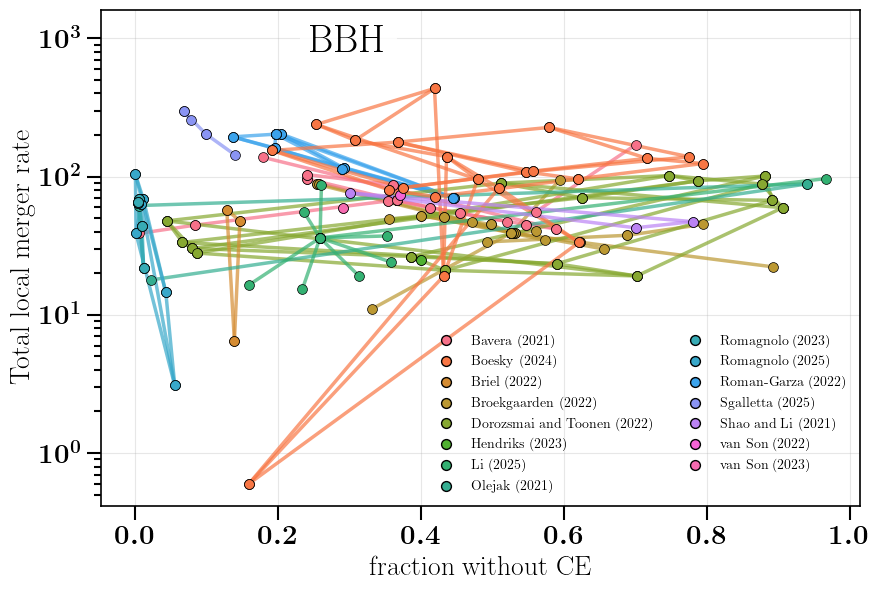

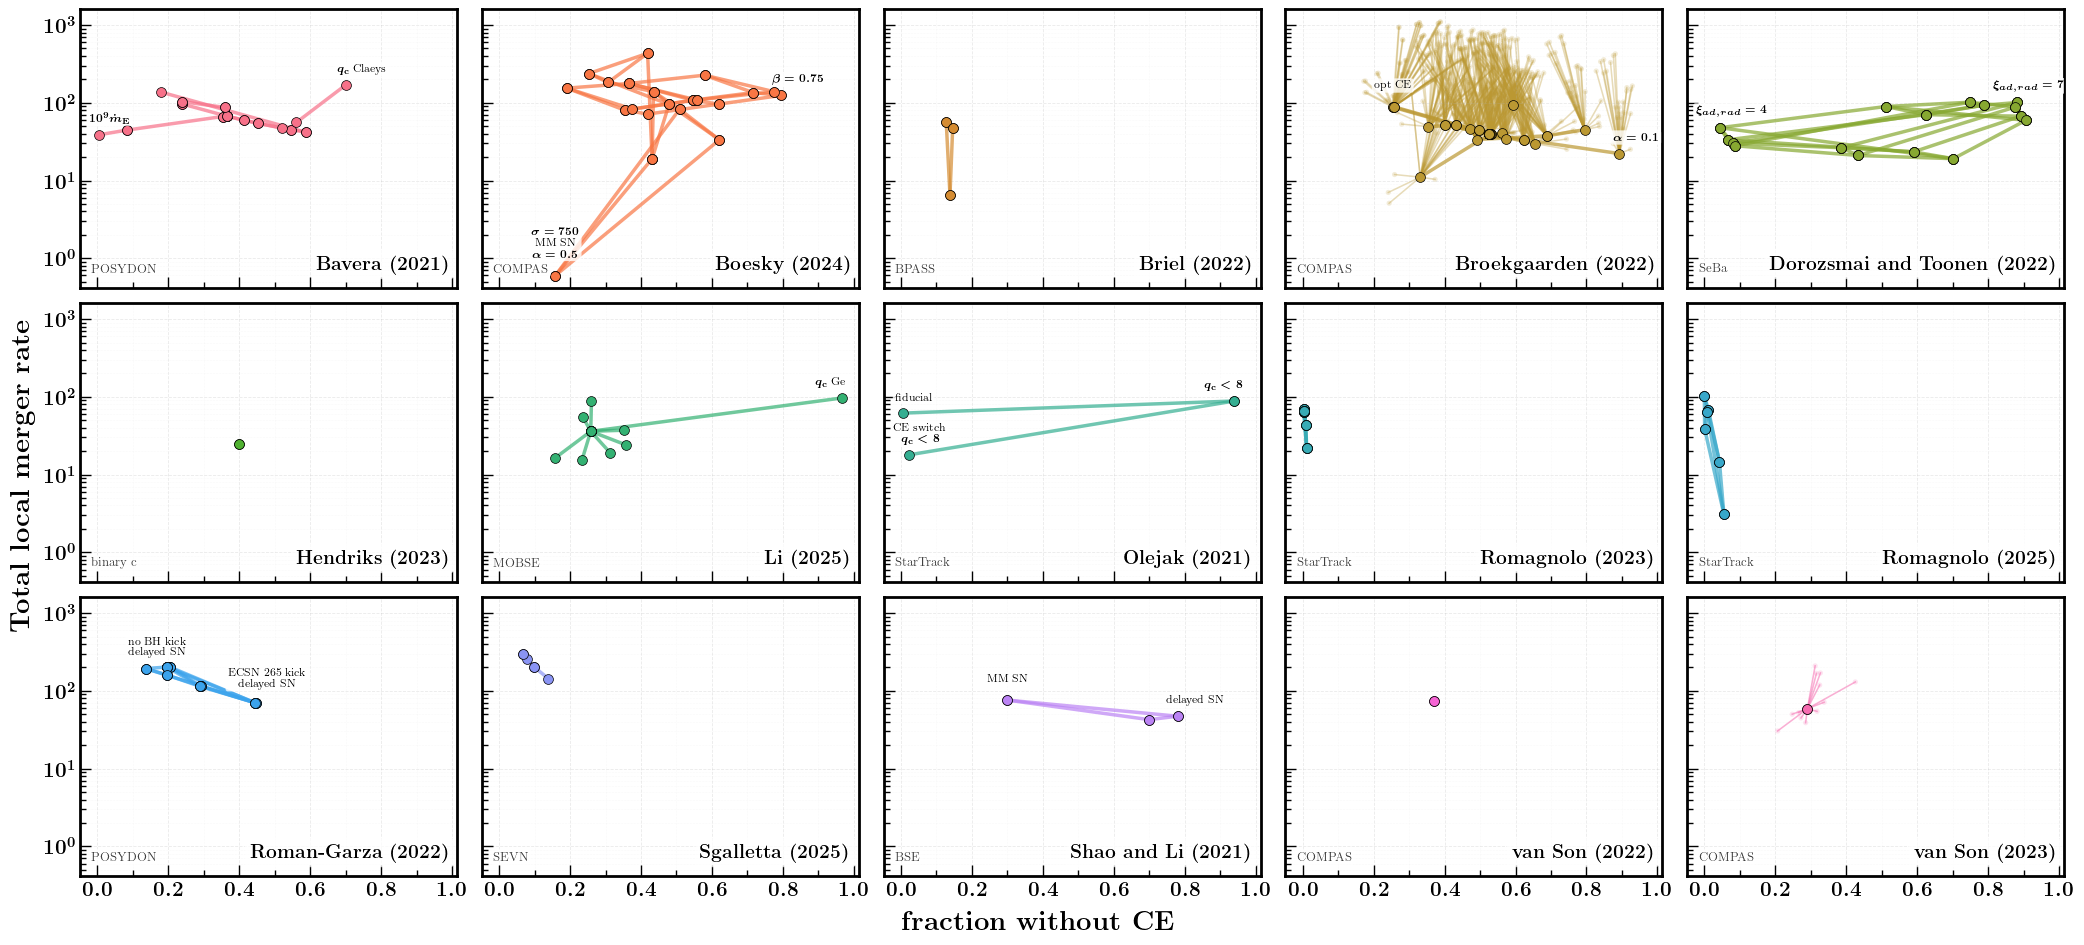


Running for BH-NS
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/figures/
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/fc_data/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_BHNS_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 560
Saved big plot to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of

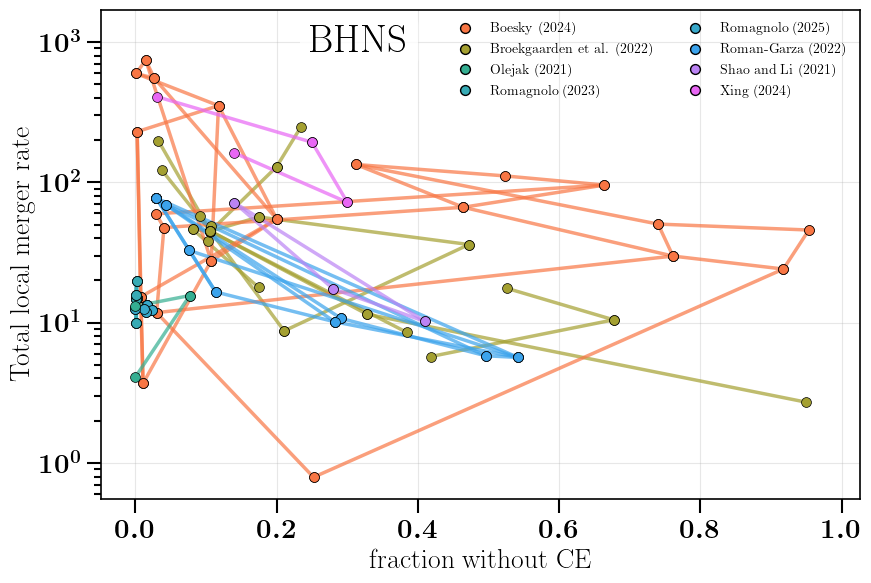

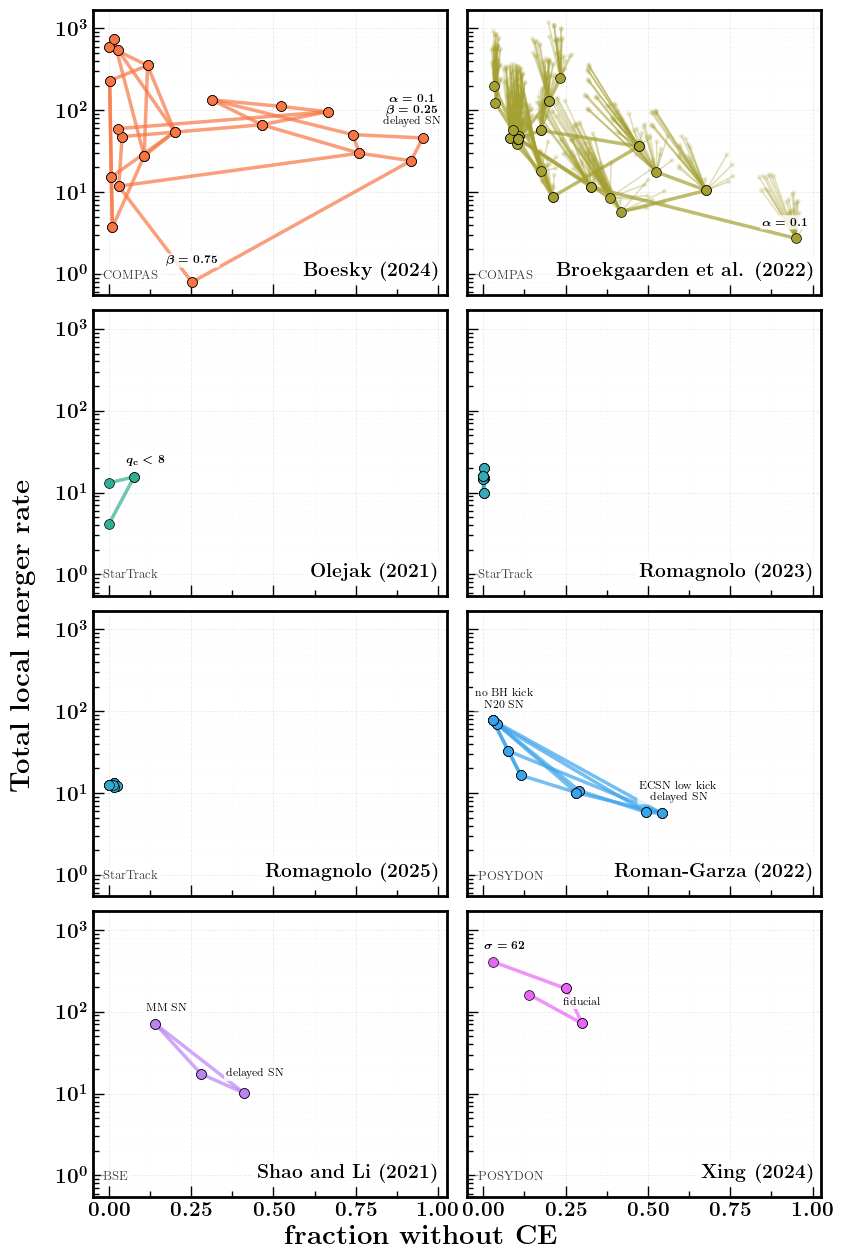


Running for NS-NS
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/figures/
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/fc_data/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_NSNS_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 560
Saved big plot to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of

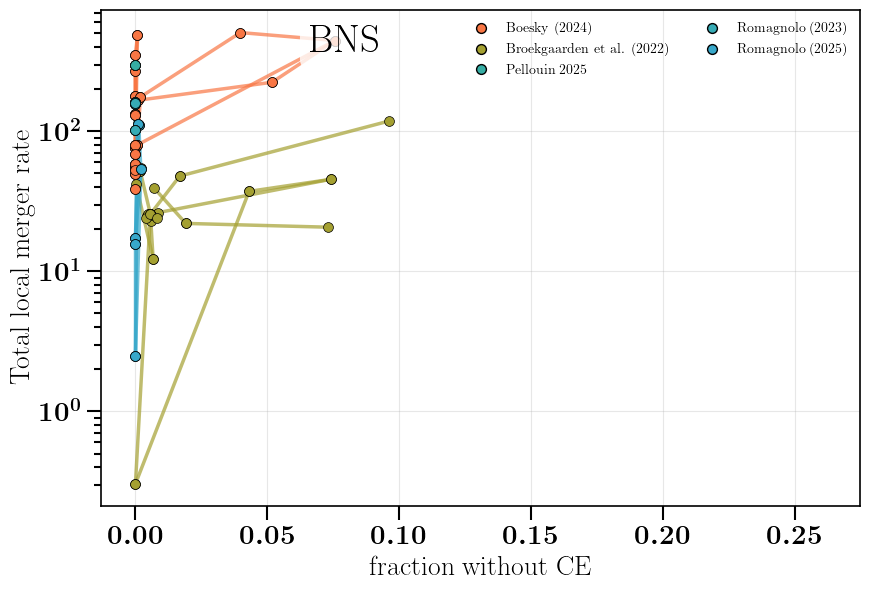

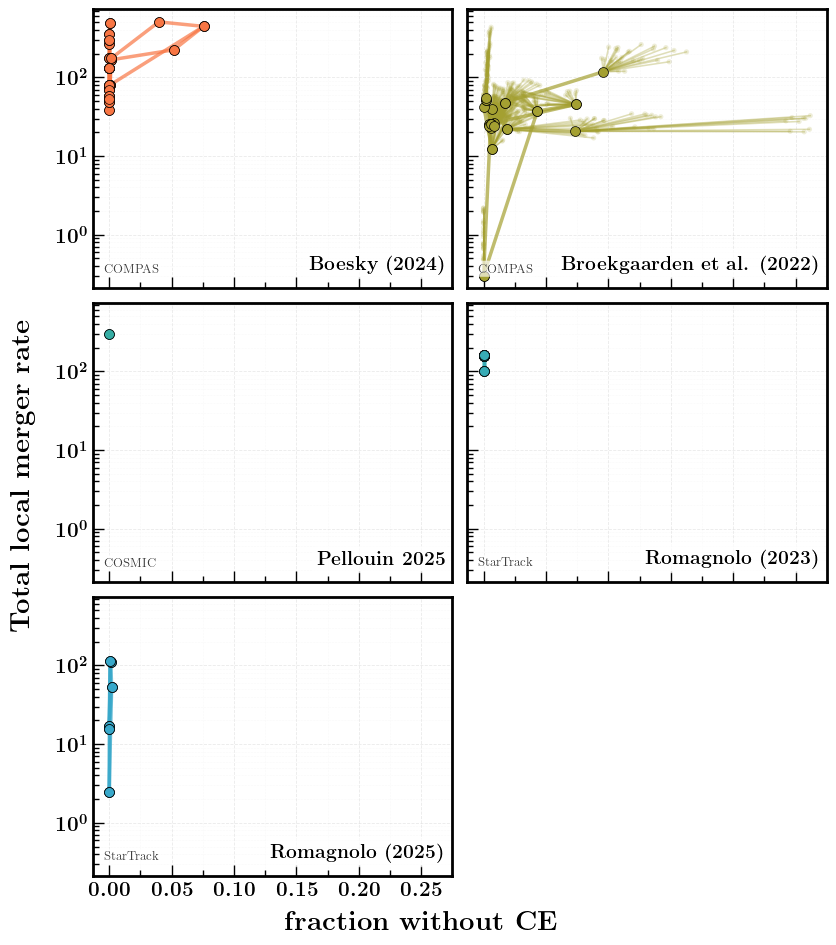

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='fraction without CE', ylabel='Total local merger rate'>,
 <Figure size 840x960 with 6 Axes>,
 array([[<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >]], dtype=object))

In [17]:
# for dco in ["BH-BH", "BH-NS", "NS-NS"]:
BBH_annotate  = ["Li25-i", "Olejak21-M480 (changedCEcriteria)", "Olejak21-M480 (changedCEcriteria)", "Olejak21-M380 (fiducial)", "Olejak21-M481 (changedCEcriteria+switch)", "B21-qcrit-Claeys", "Boesky_sigma_750_RMP_M",\
                 "B22-G-alpha0-1", "DT22-M11", "DT22-M6", "B21-eddington-1E9", "Boesky_alphaCE_0_1_beta0_75","ShaoLi_stochastic ", "ShaoLi_delayed", "RG21-noBH-kick-SN:delayed", "RG21-ECSN:Full-SN:delayed", "B22-K-optimisticCE"]
make_withoutCE_plots("BH-BH", x_quantity="fraction", annotate_models=BBH_annotate, output_fig_path=path_to_save_fig, data_path=path_to_file )


BHNS_annotate = ["B22-G-alpha0-1", "ShaoLi_delayed", "ShaoLi_stochastic ", "Boesky_alphaCE_0_1_beta0_25", "Boesky_alphaCE_0_1_beta0_75", "Olejak21-M480 (changedCEcriteria)",\
                "RG21-SN:delayed", "RG21-noBHkick-SN:N20", "Xing24_fiducial", "Xing24_sigma_61_6"] 
make_withoutCE_plots(DCOlabel="BH-NS", ncols_grid=2, x_quantity="fraction", annotate_models=BHNS_annotate, output_fig_path=path_to_save_fig, data_path=path_to_file)


make_withoutCE_plots(DCOlabel="NS-NS", ncols_grid=2, x_quantity="fraction", output_fig_path=path_to_save_fig, data_path=path_to_file)



# Interactive plots html 



In [18]:
# --- Required imports (add these at the top of your notebook/script) ---
import os
import math
import re
import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import seaborn as sns

from typing import Optional


def plot_withoutCE_by_study_plotly(
    path_to_file: str,
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols_grid: int = 4,
    panel_w: float = 360,   # pixels per panel (width)
    panel_h: float = 290,   # pixels per panel (height)
    marker_size: int = 9,
    line_width: float = 2.5,
    line_alpha: float = 0.75,
    palette_name: str = "husl",  # seaborn palette
):
    """
    Plotly (non-FigureWidget) version of the *grid by study* plot with:
      - log10 y-axis
      - shared x/y limits across panels
      - hover text on points
      - hover text on lines via invisible midpoint markers (no visual kinks)
      - dropdown toggle by "parameter families" inferred from travel_label
      - HTML export via fig.write_html(...)

    Returns:
      - plotly.graph_objects.Figure
    """

#     # ---------- helper: parameter family inferred from travel_label ----------
#     def parameter_family_from_travel_label(travel_label: str) -> str:
#         s = str(travel_label).strip()
#         if (not s) or (s.lower() == "nan"):
#             return "unknown"

#         # remove LaTeX $...$ delimiters
#         s = s.replace("$", "").strip()

#         # remove arrow tokens
#         s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
#         s = s.replace("↑", "").replace("↓", "")

#         # normalize spaces
#         s = re.sub(r"\s+", " ", s).strip()
#         return s if s else "unknown"

    # ---------- load relations ----------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # ---------- load rates ----------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file)).fillna(0.0)
    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    df_rates = df_rates.set_index("model")
    
    
    # ---------- load extra van Son (2023) S(Z,z) variations ----------
    extra_sfrd_file = os.path.join(path_to_file, "extra_fc_rates", "vanSon2023_sfrd.csv")
    if os.path.exists(extra_sfrd_file):
        df_rates_vanson_sfrd = pd.read_csv(extra_sfrd_file).fillna(0.0).set_index("model")
    else:
        df_rates_vanson_sfrd = None

    vanSon_legend = "van Son (2023) "
    vanSon_fiducial_model = "van Son (2023) "

    # ---------- infer y-column header via obtain_fc_dict ----------
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
    yname = r"Total Merger Rate [Gpc3/yr]" #"[Gpc$^{-3}$ yr$^{-1}$] " # [Gpc$^{-3}$ yr$^{-1}$]" #fc_dict["total"]["axlabel"]

    channels = fc_dict["CE_simple"]["channels"]
    channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")
    xname = channel_dict["axlabel"]

    if fc_total_header not in df_rates.columns:
        raise ValueError(
            f"Could not find total-rate column '{fc_total_header}' in rates file. "
            f"Available columns: {list(df_rates.columns)}"
        )
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")

    # ---------- load simulation specs for point hover labels ----------
    specs_path = os.path.join(path_to_file, specs_file)
    if not os.path.exists(specs_path):
        raise FileNotFoundError(f"Could not find simulation specs file: {specs_path}")

    df_specs = pd.read_csv(specs_path)
    if "model" not in df_specs.columns:
        raise ValueError("simulation_specs.csv must include a 'model' column.")
    df_specs = df_specs.set_index("model")
    
    if "using" not in df_rel.columns:
        raise ValueError(f"{relation_file} must include a 'using' column for family dropdowns.")
    

    label_cols = [c for c in ["label_1", "label_2", "label_3", "label_4"] if c in df_specs.columns]

    # ---------- global axis limits (shared across all panels) ----------
    xvals = df_rates["fraction without common envelope"].astype(float).values
    yvals = df_rates[fc_total_header].astype(float).values

    # Remove non-positive values for log scale safety
    yvals_pos = yvals[yvals > 0]
    if len(yvals_pos) == 0:
        raise ValueError("All y-values are non-positive; cannot use log axis.")

    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals_pos), np.nanmax(yvals_pos)

    # Add small padding so points are not on edges
    xpad = 0.02 * (xmax - xmin) if xmax > xmin else 0.05
    xmin -= xpad
    xmax += xpad

    # log padding in multiplicative space
    ymin /= 1.2
    ymax *= 1.2

    def point_hover_text(model: str) -> str:
        """Build hover text for a point using label_1..label_4 (only non-empty)."""
        lines = [f"<b>{model}</b>"]
        if model in df_specs.index and label_cols:
            vals = []
            for c in label_cols:
                v = df_specs.loc[model, c]
                if pd.notna(v):
                    s = str(v).strip()
                    if s and s.lower() != "nan":
                        vals.append(s)
            if vals:
                lines.append("<br>".join(vals))
        return "<br>".join(lines)

    def line_hover_text(row: pd.Series) -> str:
        tl = str(row.get("travel_label", "")).strip()
        fo = str(row.get("from_option", "")).strip()
        to = str(row.get("to_option", "")).strip()
        return f"change: {tl}: from {fo} to {to}"
    
    
    def add_vanSon2023_sfrd_overlay(fig, leg, row_i, col_i, color_map):
        """
        Add extra van Son (2023) S(Z,z) variation points/lines to the van Son panel only.
        """
        if df_rates_vanson_sfrd is None:
            return
        if str(leg).strip() != str(vanSon_legend).strip():
            return
        if vanSon_fiducial_model not in df_rates.index:
            return

        x_fid = float(df_rates.loc[vanSon_fiducial_model, "fraction without common envelope"])
        y_fid = float(df_rates.loc[vanSon_fiducial_model, fc_total_header])

        if y_fid <= 0:
            return

        this_color = color_map[leg]

        for model in df_rates_vanson_sfrd.index:
            # skip duplicate fiducial row in extra file, if present
            if "fiducial" in str(model).strip().lower():
                continue

            x = float(df_rates_vanson_sfrd.loc[model, "fraction without common envelope"])
            y = float(df_rates_vanson_sfrd.loc[model, fc_total_header])

            if y <= 0:
                continue

            hover_txt = (
                f"<b>{leg.strip()}</b><br>"
                f"S(Z,z) variation<br>"
                f"{model}<br>"
                f"connected to fiducial"
            )

            # midpoint for hover on log-y axis
            mx = 0.5 * (x_fid + x)
            my = 10 ** (0.5 * (np.log10(y_fid) + np.log10(y)))

            # background line
            fig.add_trace(
                go.Scatter(
                    x=[x_fid, x],
                    y=[y_fid, y],
                    mode="lines",
                    line=dict(width=line_width * 0.9, color=this_color),
                    opacity=0.35,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family="S(Z,z) variations", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # visible point
            fig.add_trace(
                go.Scatter(
                    x=[x],
                    y=[y],
                    mode="markers",
                    marker=dict(
                        size=max(6, marker_size - 1),
                        color=this_color,
                        line=dict(width=0.0, color=this_color),
                        opacity=0.75,
                    ),
                    hovertemplate=f"{hover_txt}<extra></extra>",
                    showlegend=False,
                    meta=dict(kind="point", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # invisible hover marker for the connecting line
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family="S(Z,z) variations", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

    # ---------- studies + colors ----------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    n_studies = len(legends_sorted)

    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    palette = sns.color_palette(palette_name, n_studies)

    def to_rgb_str(rgb_tuple):
        r, g, b = [int(round(255 * x)) for x in rgb_tuple]
        return f"rgb({r},{g},{b})"

    color_map = {leg: to_rgb_str(palette[i]) for i, leg in enumerate(legends_sorted)}

    # ---------- make subplot figure ----------
    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=legends_sorted,
        shared_xaxes=True,
        shared_yaxes=True,
        horizontal_spacing=0.02,
        vertical_spacing=0.1,
    )

    # ---------- add traces per study ----------
    for i, leg in enumerate(legends_sorted):
        row_i = i // ncols + 1
        col_i = i % ncols + 1

        df_sub = df_rel[df_rel["legend"] == leg].copy()

        # Collect unique models used in this study (for point trace)
        models = pd.unique(df_sub[["from_modelname", "to_modelname"]].values.ravel("K"))
        models = [m for m in models if isinstance(m, str) and m in df_rates.index]

        xs, ys, hovers = [], [], []
        for m in models:
            xs.append(float(df_rates.loc[m, "fraction without common envelope"]))
            ys.append(float(df_rates.loc[m, fc_total_header]))
            hovers.append(point_hover_text(m))

        # Points (one trace per panel)
        fig.add_trace(
            go.Scatter(
                x=xs,
                y=ys,
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_map[leg],
                    line=dict(width=0.8, color="black"),
                    opacity=1.0,
                ),
                hovertemplate="%{text}<extra></extra>",
                text=hovers,
                showlegend=False,
                meta=dict(kind="point", study=str(leg)),
            ),
            row=row_i,
            col=col_i,
        )

        # Lines + invisible hover markers (hover text without FigureWidget callbacks)
        for _, rr in df_sub.iterrows():
            m_from = rr.get("from_modelname", None)
            m_to = rr.get("to_modelname", None)

            if not (isinstance(m_from, str) and isinstance(m_to, str)):
                continue
            if m_from not in df_rates.index or m_to not in df_rates.index:
                continue

            x1 = float(df_rates.loc[m_from, "fraction without common envelope"])
            y1 = float(df_rates.loc[m_from, fc_total_header])
            x2 = float(df_rates.loc[m_to, "fraction without common envelope"])
            y2 = float(df_rates.loc[m_to, fc_total_header])

            # skip non-positive y (log safety)
            if y1 <= 0 or y2 <= 0:
                continue

            hover_txt = line_hover_text(rr)

#             m_from_using = ""
#             m_to_using = ""

#             if m_from in df_specs.index and "using" in df_specs.columns:
#                 m_from_using = str(df_specs.loc[m_from, "using"]).strip()

#             if m_to in df_specs.index and "using" in df_specs.columns:
#                 m_to_using = str(df_specs.loc[m_to, "using"]).strip()

#             # Usually the varied model is the "to" model, so prefer that.
#             family = m_to_using if m_to_using and m_to_using.lower() != "nan" else m_from_using

#             if not family or family.lower() == "nan":
#                 family = "unknown"
            family = str(rr.get("using", "")).strip()

            if not family or family.lower() == "nan":
                family = "unknown"  

            # Midpoint for log-y axis: geometric mean keeps straightness
            mx = 0.5 * (x1 + x2)
            my = 10 ** (0.5 * (np.log10(y1) + np.log10(y2)))

            # 1) Draw straight line (no hover)
            fig.add_trace(
                go.Scatter(
                    x=[x1, x2],
                    y=[y1, y2],
                    mode="lines",
                    line=dict(width=line_width, color=color_map[leg]),
                    opacity=line_alpha,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # 2) Invisible hover marker at midpoint (drives the hover text)
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )
            
        # Add van Son (2023) extra S(Z,z) variations in the van Son panel
        add_vanSon2023_sfrd_overlay(fig, leg, row_i, col_i, color_map)

        # Axes per panel
        fig.update_xaxes(type="linear", range=[xmin, xmax], row=row_i, col=col_i)
        fig.update_yaxes(type="log", range=[np.log10(ymin), np.log10(ymax)], row=row_i, col=col_i)

    # Turn off unused panels
    for j in range(n_studies, nrows * ncols):
        r = j // ncols + 1
        c = j % ncols + 1
        fig.update_xaxes(visible=False, row=r, col=c)
        fig.update_yaxes(visible=False, row=r, col=c)

    # Layout
    fig.update_layout(
        width=int(panel_w * ncols),
        height=int(panel_h * nrows) + 80,
        margin=dict(l=70, r=160, t=70, b=70),
        hovermode="closest",
        hoverdistance=40,
    )

    # Add x-label to every subplot
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            # Skip unused panels
            idx = (r - 1) * ncols + (c - 1)
            if idx >= n_studies:
                continue

            fig.update_xaxes(
                title_text=f"<b>{xname}</b>",
                row=r,
                col=c
            )
            
    # Add y-label to every subplot
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            # Skip unused panels
            idx = (r - 1) * ncols + (c - 1)
            if c == 1:  # only first column:
                fig.update_yaxes(
                    title_text=yname,
                    row=r,
                    col=c
                )

    # Subplot title styling
    fig.update_annotations(font=dict(size=14))

    # ---------- Dropdown: Toggle parameter families ----------
    families = set()
    for tr in fig.data:
        meta = getattr(tr, "meta", None) or {}
        if meta.get("kind") in ("line", "hover"):
            families.add(meta.get("family", "unknown"))
    families = sorted(families)

    def visibility_for_family(fam: Optional[str]):
        """fam=None shows all; else show only traces for that family. Points always visible."""
        vis = []
        for tr in fig.data:
            meta = getattr(tr, "meta", None) or {}
            kind = meta.get("kind", None)
            if kind == "point" or kind is None:
                vis.append(True)
            elif kind in ("line", "hover"):
                vis.append(True if fam is None else (meta.get("family") == fam))
            else:
                vis.append(True)
        return vis

    buttons = [dict(label="All families", method="update", args=[{"visible": visibility_for_family(None)}])]
    for fam in families:
        buttons.append(dict(label=str(fam), method="update", args=[{"visible": visibility_for_family(fam)}]))

    fig.update_layout(
        updatemenus=[
            dict(
                type="dropdown",
                x=1.02,
                y=1.02,
                xanchor="left",
                yanchor="top",
                buttons=buttons,
            )
        ]
    )

    return fig




# BH-BH 

In [19]:
# ---- Example usage ----
DCOlabel = "BH-BH"

fig = plot_withoutCE_by_study_plotly(
    path_to_file=path_to_file,
    DCOlabel="BH-BH",
    ncols_grid=5,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out = path_interactive_fig + 'Fig9_' +  "BH-BH_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/interactive_figures_and_tables/Fig9_BH-BH_by_study_interactive.html


True

# BH-NS 

In [20]:
# ---- Example usage ----
DCOlabel = "BH-NS"

fig = plot_withoutCE_by_study_plotly(
    path_to_file=path_to_file,
    DCOlabel=DCOlabel,
    ncols_grid=4,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out =  path_interactive_fig + 'Fig10_' +  DCOlabel + "_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/interactive_figures_and_tables/Fig10_BH-NS_by_study_interactive.html


True

# NS-NS 

In [21]:
# ---- Example usage ----
DCOlabel = "NS-NS"

fig = plot_withoutCE_by_study_plotly(
    path_to_file=path_to_file,
    DCOlabel=DCOlabel,
    ncols_grid=5,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out = path_interactive_fig + 'Fig11_' +  DCOlabel + "_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/interactive_figures_and_tables/Fig11_NS-NS_by_study_interactive.html


True

In [9]:
## make extra interactive figures that show absolute rates


In [23]:
# --- Required imports ---
import os
import math
import re
import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import seaborn as sns
from typing import Optional


def plot_ce_vs_withoutce_rate_by_study_plotly(
    path_to_file: str,
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols_grid: int = 4,
    panel_w: float = 360,   # pixels per panel
    panel_h: float = 290,   # pixels per panel
    marker_size: int = 9,
    line_width: float = 2.5,
    line_alpha: float = 0.75,
    palette_name: str = "husl",
    add_dropdown: bool = True,
):
    """
    Plotly grid-by-study plot where:
      x = rate without CE = (fraction without CE) * total rate
      y = rate with CE    = (fraction with CE)    * total rate

    Both axes are logarithmic.

    Returns
    -------
    plotly.graph_objects.Figure
    """

    # ---------- helper: parameter family inferred from travel_label ----------
    def parameter_family_from_travel_label(travel_label: str) -> str:
        s = str(travel_label).strip()
        if (not s) or (s.lower() == "nan"):
            return "unknown"

        s = s.replace("$", "").strip()
        s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
        s = s.replace("↑", "").replace("↓", "")
        s = re.sub(r"\s+", " ", s).strip()
        return s if s else "unknown"

    # ---------- load relations ----------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # ---------- load rates ----------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file)).fillna(0.0)

    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    df_rates = df_rates.set_index("model")

    # ---------- infer total-rate column from obtain_fc_dict ----------
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]

    required_cols = [
        "fraction without common envelope",
        "fraction with common envelope",
        fc_total_header,
    ]
    missing = [c for c in required_cols if c not in df_rates.columns]
    if missing:
        raise ValueError(f"Missing required columns in rates file: {missing}")

    # ---------- load simulation specs for hover labels ----------
    specs_path = os.path.join(path_to_file, specs_file)
    if not os.path.exists(specs_path):
        raise FileNotFoundError(f"Could not find simulation specs file: {specs_path}")

    df_specs = pd.read_csv(specs_path)
    if "model" not in df_specs.columns:
        raise ValueError("simulation_specs.csv must include a 'model' column.")
    df_specs = df_specs.set_index("model")

    label_cols = [c for c in ["label_1", "label_2", "label_3", "label_4"] if c in df_specs.columns]

    # ---------- define derived rate coordinates ----------
    total_rate = df_rates[fc_total_header].astype(float)
    frac_without = df_rates["fraction without common envelope"].astype(float)
    frac_with = df_rates["fraction with common envelope"].astype(float)

    df_rates["rate_without_CE"] = frac_without * total_rate
    df_rates["rate_with_CE"] = frac_with * total_rate

    xcol = "rate_without_CE"
    ycol = "rate_with_CE"

    xname = r"without CE rate [Gpc-3/yr]"
    yname = r"with CE rate [Gpc-3/yr]"

    # ---------- global axis limits ----------
    xvals = df_rates[xcol].astype(float).values
    yvals = df_rates[ycol].astype(float).values

    # Keep only positive values for log axes
    xvals_pos = xvals[np.isfinite(xvals) & (xvals > 0)]
    yvals_pos = yvals[np.isfinite(yvals) & (yvals > 0)]

    if len(xvals_pos) == 0:
        raise ValueError("All x-values are non-positive; cannot use log x-axis.")
    if len(yvals_pos) == 0:
        raise ValueError("All y-values are non-positive; cannot use log y-axis.")

    xmin, xmax = np.nanmin(xvals_pos), np.nanmax(xvals_pos)
    ymin, ymax = np.nanmin(yvals_pos), np.nanmax(yvals_pos)

    # multiplicative padding for log axes
    xmin /= 1.25
    xmax *= 1.25
    ymin /= 1.25
    ymax *= 1.25

    # ---------- hover helpers ----------
    def point_hover_text(model: str) -> str:
        lines = [f"<b>{model}</b>"]

        if model in df_specs.index and label_cols:
            vals = []
            for c in label_cols:
                v = df_specs.loc[model, c]
                if pd.notna(v):
                    s = str(v).strip()
                    if s and s.lower() != "nan":
                        vals.append(s)
            if vals:
                lines.append("<br>".join(vals))

        if model in df_rates.index:
            x = df_rates.loc[model, xcol]
            y = df_rates.loc[model, ycol]
            rtot = df_rates.loc[model, fc_total_header]
            fwo = df_rates.loc[model, "fraction without common envelope"]
            fwi = df_rates.loc[model, "fraction with common envelope"]

            lines.append(
                f"<br>"
                f"R_without CE = {x:.3e}<br>"
                f"R_with CE = {y:.3e}<br>"
                f"R_total = {rtot:.3e}<br>"
                f"f_without CE = {fwo:.3f}<br>"
                f"f_with CE = {fwi:.3f}"
            )

        return "<br>".join(lines)

    def line_hover_text(row: pd.Series, m_from: str, m_to: str) -> str:
        tl = str(row.get("travel_label", "")).strip()
        fo = str(row.get("from_option", "")).strip()
        to = str(row.get("to_option", "")).strip()
        return (
            f"<b>{m_from}</b> → <b>{m_to}</b><br>"
            f"change: {tl}: from {fo} to {to}"
        )

    # ---------- studies + colors ----------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    n_studies = len(legends_sorted)

    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    palette = sns.color_palette(palette_name, n_studies)

    def to_rgb_str(rgb_tuple):
        r, g, b = [int(round(255 * x)) for x in rgb_tuple]
        return f"rgb({r},{g},{b})"

    color_map = {leg: to_rgb_str(palette[i]) for i, leg in enumerate(legends_sorted)}

    # ---------- make subplot figure ----------
    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=legends_sorted,
        shared_xaxes=True,
        shared_yaxes=True,
        horizontal_spacing=0.02,
        vertical_spacing=0.10,
    )

    # ---------- add traces per study ----------
    for i, leg in enumerate(legends_sorted):
        row_i = i // ncols + 1
        col_i = i % ncols + 1

        df_sub = df_rel[df_rel["legend"] == leg].copy()

        # --- collect unique models for this panel ---
        models = pd.unique(df_sub[["from_modelname", "to_modelname"]].values.ravel("K"))
        models = [m for m in models if isinstance(m, str) and m in df_rates.index]

        xs, ys, hovers = [], [], []
        for m in models:
            x = float(df_rates.loc[m, xcol])
            y = float(df_rates.loc[m, ycol])

            # log-axis safety
            if (not np.isfinite(x)) or (not np.isfinite(y)) or x <= 0 or y <= 0:
                continue

            xs.append(x)
            ys.append(y)
            hovers.append(point_hover_text(m))

        # points
        fig.add_trace(
            go.Scatter(
                x=xs,
                y=ys,
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_map[leg],
                    line=dict(width=0.8, color="black"),
                    opacity=1.0,
                ),
                hovertemplate="%{text}<extra></extra>",
                text=hovers,
                showlegend=False,
                meta=dict(kind="point", study=str(leg)),
            ),
            row=row_i,
            col=col_i,
        )

        # lines + invisible midpoint hover markers
        for _, rr in df_sub.iterrows():
            m_from = rr.get("from_modelname", None)
            m_to = rr.get("to_modelname", None)

            if not (isinstance(m_from, str) and isinstance(m_to, str)):
                continue
            if m_from not in df_rates.index or m_to not in df_rates.index:
                continue

            x1 = float(df_rates.loc[m_from, xcol])
            y1 = float(df_rates.loc[m_from, ycol])
            x2 = float(df_rates.loc[m_to, xcol])
            y2 = float(df_rates.loc[m_to, ycol])

            # log safety
            if (
                (not np.isfinite(x1)) or (not np.isfinite(y1)) or
                (not np.isfinite(x2)) or (not np.isfinite(y2)) or
                x1 <= 0 or y1 <= 0 or x2 <= 0 or y2 <= 0
            ):
                continue

            hover_txt = line_hover_text(rr, m_from, m_to)
            family = parameter_family_from_travel_label(rr.get("travel_label", ""))

            # midpoint in log-log space
            mx = 10 ** (0.5 * (np.log10(x1) + np.log10(x2)))
            my = 10 ** (0.5 * (np.log10(y1) + np.log10(y2)))

            # visible line
            fig.add_trace(
                go.Scatter(
                    x=[x1, x2],
                    y=[y1, y2],
                    mode="lines",
                    line=dict(width=line_width, color=color_map[leg]),
                    opacity=line_alpha,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # invisible hover marker
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

        # axes per panel
        fig.update_xaxes(
            type="log",
            range=[np.log10(xmin), np.log10(xmax)],
            row=row_i,
            col=col_i
        )
        fig.update_yaxes(
            type="log",
            range=[np.log10(ymin), np.log10(ymax)],
            row=row_i,
            col=col_i
        )
        
        
        
        # --- Add diagonal 1:1 line (R_withCE = R_withoutCE) ---
        # Use global limits so all panels share the same reference
        diag_min = max(xmin, ymin)
        diag_max = min(xmax, ymax)

        if diag_min > 0 and diag_max > diag_min:
            fig.add_trace(
                go.Scatter(
                    x=[diag_min, diag_max],
                    y=[diag_min, diag_max],
                    mode="lines",
                    line=dict(
                        color="black",
                        width=1.5,
                        dash="dash"
                    ),
                    opacity=0.7,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="reference"),
                ),
                row=row_i,
                col=col_i,
            )        
    
    
#         # --- Add annotations: CE-dominated / SMT-dominated ---
#         # Place them relative to axis limits (log-safe positioning)

#         # --- Add annotations: CE-dominated / SMT-dominated ---
#         # Use explicit subplot axis references instead of row/col
#         axis_index = i + 1
#         xref = f"x{axis_index}" if axis_index > 1 else "x"
#         yref = f"y{axis_index}" if axis_index > 1 else "y"

#         x_ce  = 10 ** (0.70 * np.log10(xmin) + 0.30 * np.log10(xmax))
#         y_ce  = 10 ** (0.30 * np.log10(ymin) + 0.70 * np.log10(ymax))

#         x_smt = 10 ** (0.30 * np.log10(xmin) + 0.70 * np.log10(xmax))
#         y_smt = 10 ** (0.70 * np.log10(ymin) + 0.30 * np.log10(ymax))

#         fig.add_annotation(
#             x=x_ce,
#             y=y_ce,
#             xref=xref,
#             yref=yref,
#             text="CE-dominated",
#             showarrow=False,
#             font=dict(size=10, color="rgba(0,0,0,0.55)"),
#             align="left",
#             bgcolor="rgba(255,255,255,0.35)",
#             borderpad=2,
#             xanchor="left",
#             yanchor="bottom",
#         )

#         fig.add_annotation(
#             x=x_smt,
#             y=y_smt,
#             xref=xref,
#             yref=yref,
#             text="SMT-dominated",
#             showarrow=False,
#             font=dict(size=10, color="rgba(0,0,0,0.55)"),
#             align="right",
#             bgcolor="rgba(255,255,255,0.35)",
#             borderpad=2,
#             xanchor="right",
#             yanchor="top",
#         )
    
    

    # ---------- turn off unused panels ----------
    for j in range(n_studies, nrows * ncols):
        r = j // ncols + 1
        c = j % ncols + 1
        fig.update_xaxes(visible=False, row=r, col=c)
        fig.update_yaxes(visible=False, row=r, col=c)

    # ---------- layout ----------
    fig.update_layout(
        width=int(panel_w * ncols),
        height=int(panel_h * nrows) + 80,
        margin=dict(l=70, r=160 if add_dropdown else 40, t=70, b=70),
        hovermode="closest",
        hoverdistance=40,
    )

    # ---------- x-labels on every used subplot ----------
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            idx = (r - 1) * ncols + (c - 1)
            if idx >= n_studies:
                continue

            fig.update_xaxes(
                title_text=f"<b>{xname}</b>",
                row=r,
                col=c
            )

    # ---------- y-labels only on first column ----------
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            idx = (r - 1) * ncols + (c - 1)
            if idx >= n_studies:
                continue
            if c == 1:
                fig.update_yaxes(
                    title_text=yname,
                    row=r,
                    col=c
                )

    # subplot title styling
#     fig.update_annotations(font=dict(size=14))

    # ---------- dropdown ----------
    if add_dropdown:
        families = set()
        for tr in fig.data:
            meta = getattr(tr, "meta", None) or {}
            if meta.get("kind") in ("line", "hover"):
                families.add(meta.get("family", "unknown"))
        families = sorted(families)

        def visibility_for_family(fam: Optional[str]):
            vis = []
            for tr in fig.data:
                meta = getattr(tr, "meta", None) or {}
                kind = meta.get("kind", None)
                if kind == "point" or kind is None:
                    vis.append(True)
                elif kind in ("line", "hover"):
                    vis.append(True if fam is None else (meta.get("family") == fam))
                else:
                    vis.append(True)
            return vis

        buttons = [
            dict(
                label="All families",
                method="update",
                args=[{"visible": visibility_for_family(None)}]
            )
        ]
        for fam in families:
            buttons.append(
                dict(
                    label=str(fam),
                    method="update",
                    args=[{"visible": visibility_for_family(fam)}]
                )
            )

        fig.update_layout(
            updatemenus=[
                dict(
                    type="dropdown",
                    x=1.02,
                    y=1.02,
                    xanchor="left",
                    yanchor="top",
                    buttons=buttons,
                )
            ]
        )

    return fig



In [24]:
fig = plot_ce_vs_withoutce_rate_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="BH-BH",
    ncols_grid=5,
    panel_w=360,
    panel_h=290,
    marker_size=9,
    line_width=2.5,
    palette_name="husl",
)

fig.show()

# to save the figure
out = path_interactive_fig + "BHBH_withCE_vs_withoutCE_rate_grid.html"
fig.write_html(out, include_plotlyjs="cdn")

In [13]:
fig = plot_ce_vs_withoutce_rate_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="BH-NS",
    ncols_grid=5,
    panel_w=360,
    panel_h=290,
    marker_size=9,
    line_width=2.5,
    palette_name="husl",
)

fig.show()

# to save the figure
fig.write_html("/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/interactive_figures_and_tables/BHNS_withCE_vs_withoutCE_rate_grid.html", include_plotlyjs="cdn")

In [25]:
fig = plot_ce_vs_withoutce_rate_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="NS-NS",
    ncols_grid=5,
    panel_w=360,
    panel_h=290,
    marker_size=9,
    line_width=2.5,
    palette_name="husl",
)

fig.show()

# to save the figure
out = path_interactive_fig + "BNS_withCE_vs_withoutCE_rate_grid.html"
fig.write_html(out, include_plotlyjs="cdn")

## Create non interactive plot showing absolute rates  (Appendix figures)

In [26]:
# --- Required imports ---
import os
import math
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from typing import Optional


def plot_ce_vs_withoutce_rate_by_study_static(
    path_to_file: str,
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols_grid: int = 4,
    panel_w: float = 3.6,   # inches
    panel_h: float = 3.0,   # inches
    marker_size: int = 70,
    line_width: float = 2.5,
    line_alpha: float = 0.75,
    palette_name: str = "husl",
):

    # ---------- helper ----------
    def parameter_family_from_travel_label(travel_label: str) -> str:
        s = str(travel_label).strip()

        if (not s) or (s.lower() == "nan"):
            return "unknown"

        s = s.replace("$", "").strip()
        s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
        s = s.replace("↑", "").replace("↓", "")
        s = re.sub(r"\s+", " ", s).strip()

        return s if s else "unknown"

    # ---------- load relations ----------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"

    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # ---------- load rates ----------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"

    df_rates = pd.read_csv(
        os.path.join(path_to_file, rates_file)
    ).fillna(0.0)

    df_rates = df_rates.set_index("model")

    # ---------- total-rate column ----------
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]

    total_rate = df_rates[fc_total_header].astype(float)

    frac_without = df_rates[
        "fraction without common envelope"
    ].astype(float)

    frac_with = df_rates[
        "fraction with common envelope"
    ].astype(float)

    df_rates["rate_without_CE"] = frac_without * total_rate
    df_rates["rate_with_CE"] = frac_with * total_rate

    xcol = "rate_without_CE"
    ycol = "rate_with_CE"

    # ---------- global limits ----------
    xvals = df_rates[xcol].values
    yvals = df_rates[ycol].values

    xvals = xvals[np.isfinite(xvals) & (xvals > 0)]
    yvals = yvals[np.isfinite(yvals) & (yvals > 0)]

    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals), np.nanmax(yvals)

    xmin /= 1.25
    xmax *= 1.25
    ymin /= 1.25
    ymax *= 1.25

    # ---------- studies ----------
    legends_sorted = sorted(
        df_rel["legend"].dropna().unique().tolist()
    )

    n_studies = len(legends_sorted)

    ncols = ncols_grid
    nrows = int(math.ceil(n_studies / ncols))

    palette = sns.color_palette(
        palette_name,
        n_studies
    )

    color_map = {
        leg: palette[i]
        for i, leg in enumerate(legends_sorted)
    }

    # ---------- figure ----------
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_w * ncols, panel_h * nrows),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes).flatten()

    # ---------- loop over studies ----------
    for i, leg in enumerate(legends_sorted):

        ax = axes[i]

        df_sub = df_rel[df_rel["legend"] == leg].copy()

        # --- unique models ---
        models = pd.unique(
            df_sub[["from_modelname", "to_modelname"]]
            .values.ravel("K")
        )

        models = [
            m for m in models
            if isinstance(m, str) and m in df_rates.index
        ]

        # ---------- scatter points ----------
        xs, ys = [], []

        for m in models:

            x = float(df_rates.loc[m, xcol])
            y = float(df_rates.loc[m, ycol])

            if (
                np.isfinite(x)
                and np.isfinite(y)
                and x > 0
                and y > 0
            ):
                xs.append(x)
                ys.append(y)

        ax.scatter(
            xs,
            ys,
            s=marker_size,
            color=color_map[leg],
            edgecolor="black",
            linewidth=0.7,
            zorder=3,
        )

        # ---------- connecting lines ----------
        for _, rr in df_sub.iterrows():

            m_from = rr.get("from_modelname", None)
            m_to = rr.get("to_modelname", None)

            if (
                not isinstance(m_from, str)
                or not isinstance(m_to, str)
            ):
                continue

            if (
                m_from not in df_rates.index
                or m_to not in df_rates.index
            ):
                continue

            x1 = float(df_rates.loc[m_from, xcol])
            y1 = float(df_rates.loc[m_from, ycol])

            x2 = float(df_rates.loc[m_to, xcol])
            y2 = float(df_rates.loc[m_to, ycol])

            if (
                x1 <= 0 or y1 <= 0
                or x2 <= 0 or y2 <= 0
            ):
                continue

            ax.plot(
                [x1, x2],
                [y1, y2],
                lw=line_width,
                alpha=line_alpha,
                color=color_map[leg],
                zorder=2,
            )

        # ---------- diagonal ----------
        diag_min = max(xmin, ymin)
        diag_max = min(xmax, ymax)

        ax.plot(
            [diag_min, diag_max],
            [diag_min, diag_max],
            ls="--",
            lw=1.5,
            color="black",
            alpha=0.7,
            zorder=1,
        )
        
        
        # ---------- dominance-region labels ----------
        ax.text(
            0.06, 0.82,
            "with CE\ndominates",
            transform=ax.transAxes,
            fontsize=10,
            ha="left",
            va="top",
            color="black",
            alpha=0.65,
        )

        ax.text(
            0.94, 0.08,
            "without CE\ndominates",
            transform=ax.transAxes,
            fontsize=10,
            ha="right",
            va="bottom",
            color="black",
            alpha=0.65,
        )
        
        

        # ---------- formatting ----------
        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        
        
        # ---------- soft background grid ----------
        ax.grid(
            True,
            which="major",
            linestyle="--",
            linewidth=0.6,
            alpha=0.22,
            zorder=0,
        )

        ax.grid(
            True,
            which="minor",
            linestyle=":",
            linewidth=0.4,
            alpha=0.12,
            zorder=0,
        )
        

#         ax.set_title(leg, fontsize=12)
# ---------- study label inside panel ----------
        ax.text(
            0.04, 0.96,
            leg,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="top",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
                pad=2,
            ),
        )        

        ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            labelsize=10,
        )

    # ---------- remove unused axes ----------
    for j in range(n_studies, len(axes)):
        fig.delaxes(axes[j])

    # ---------- labels ----------
    for ax in axes[:n_studies]:
        ax.set_xlabel(
            r"without CE rate [Gpc$^{-3}$ yr$^{-1}$]",
            fontsize=11,
        )

    for row in range(nrows):
        axes[row * ncols].set_ylabel(
            r"with CE rate [Gpc$^{-3}$ yr$^{-1}$]",
            fontsize=11,
        )

    plt.tight_layout()

    return fig

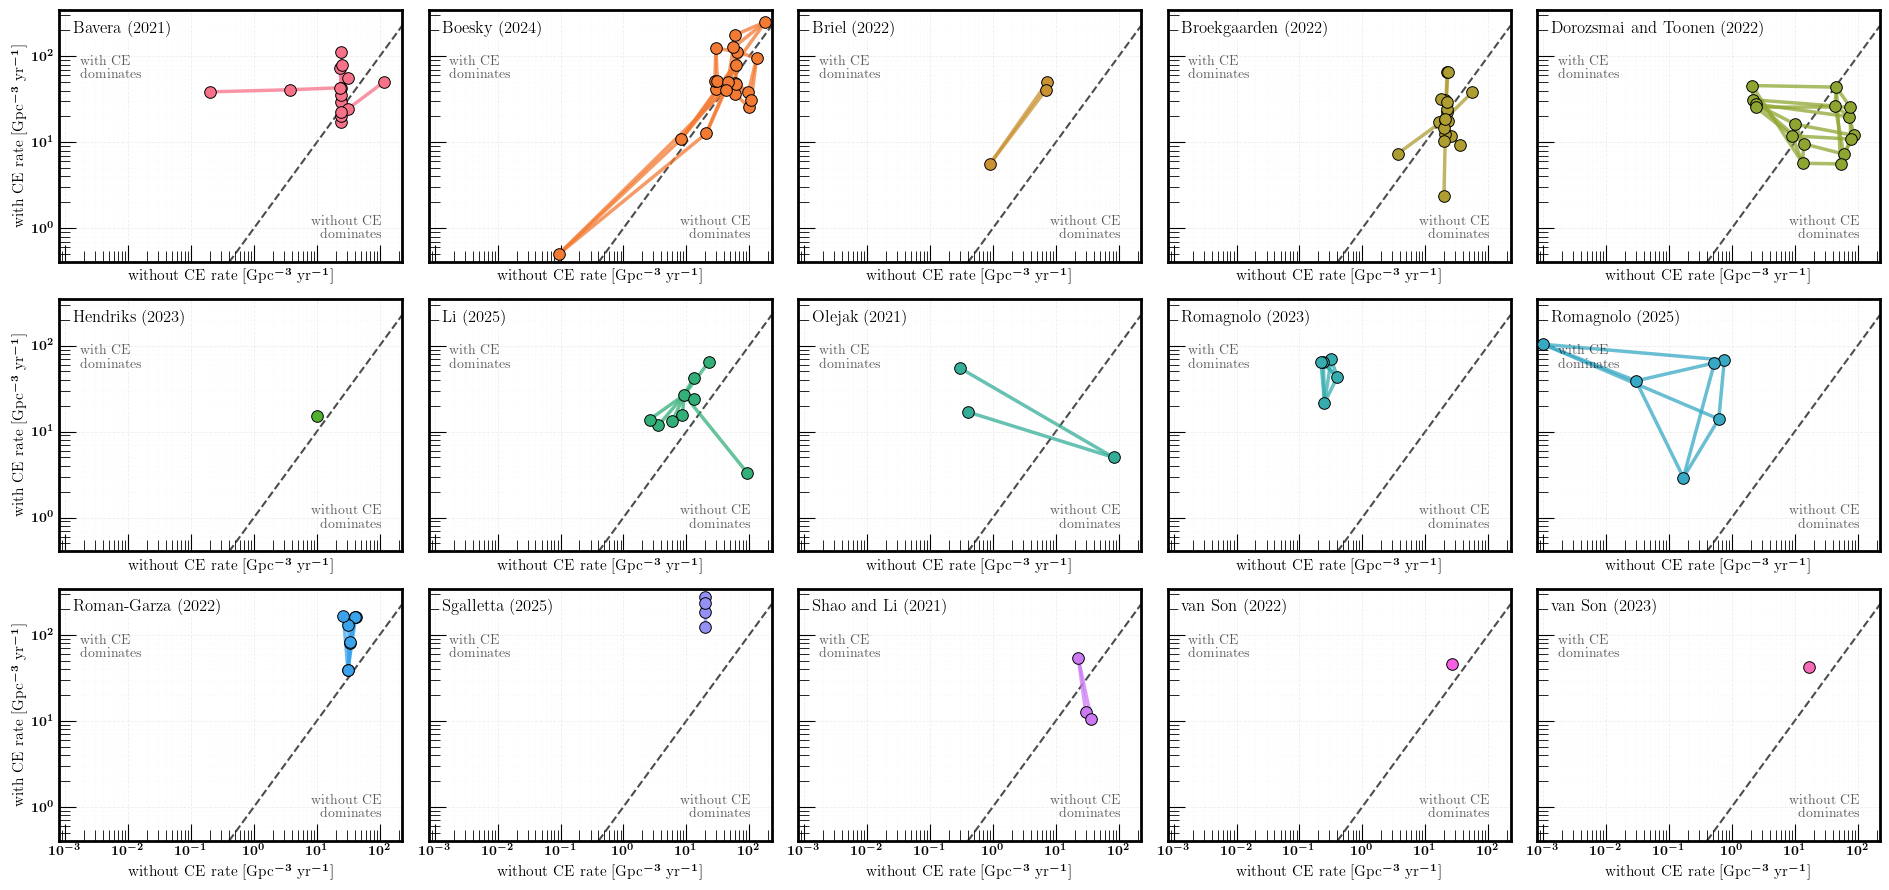

In [27]:
fig = plot_ce_vs_withoutce_rate_by_study_static(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="BH-BH",
    ncols_grid=5,
    panel_w=3.8,
    panel_h=3.0,
    marker_size=70,
    line_width=2.5,
    palette_name="husl",
)

out = path_to_save_fig + "BHBH_withCE_vs_withoutCE_rate_grid.pdf"
fig.savefig(out,
    bbox_inches="tight"
)

plt.show()

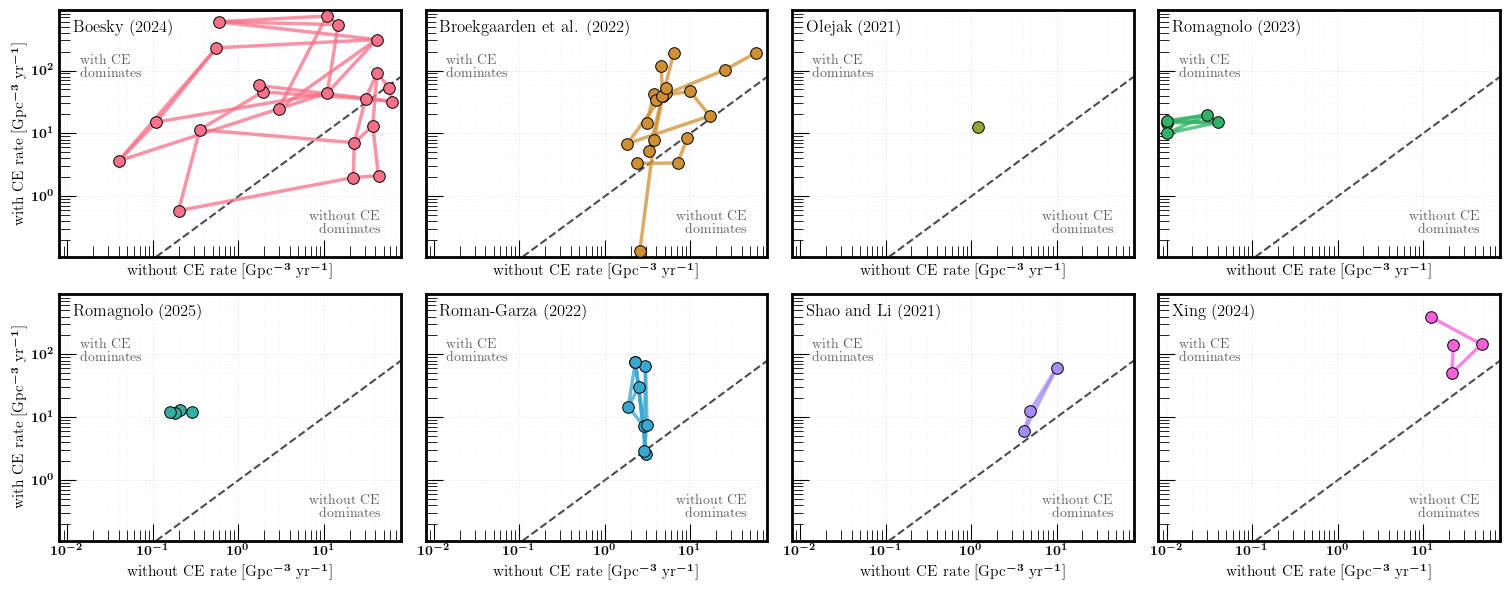

In [28]:
fig = plot_ce_vs_withoutce_rate_by_study_static(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="BH-NS",
    ncols_grid=4,
    panel_w=3.8,
    panel_h=3.0,
    marker_size=70,
    line_width=2.5,
    palette_name="husl",
)

out = path_to_save_fig + "BHNS_withCE_vs_withoutCE_rate_grid.pdf"
fig.savefig(out,
    bbox_inches="tight"
)

plt.show()

## Figure 12 and 13: change as a function of parameter BBH and BHNS & extra (interactive) plots


In [29]:
import os
import math
from typing import Sequence, Optional, Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
})


def plot_withoutCE_fraction_vs_parameters_static(
    path_to_file: str,
    parameters: Sequence[str],
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols: int = 2,
    panel_w_in: float = 5.2,
    panel_h_in: float = 2.7,
    marker_size: float = 7.0,
    line_width: float = 2.3,
    line_alpha: float = 0.85,
    palette_name: str = "husl",
    show_study_legend: bool = True,
    category_orders: Optional[Dict[str, List[str]]] = None,
    alpha_logx: bool = True,
    sigma_logx: bool = False, # whether to plot sigma in log x
    parameter_map: Optional[Dict[str, str]] = None,
    ylim: Tuple[float, float] = (0.0, 1.0),
    study_color_map=None
):
    """
    Static Matplotlib version.

    Each subplot is built from all relation rows that share the same value
    in the `using` column.

    Parameters
    ----------
    parameters : list of subplot labels requested by the user
        Example: [r"$\\beta$", r"$\\alpha$", "remnant mass prescription", r"$\\sigma$"]

    parameter_map : dict, optional
        Maps displayed panel names to values expected in df_rel["using"].
        Example:
            {
                r"$\\beta$": "beta",
                r"$\\alpha$": "alpha",
                "remnant mass prescription": "supernova",
                r"$\\sigma$": "sigma",
            }
    """






    
    # ---------------- helpers ----------------
    def normalize_text(s: Any) -> str:
        if s is None or (isinstance(s, float) and np.isnan(s)):
            return ""
        return str(s).strip()

    def normalize_key(s: Any) -> str:
        return normalize_text(s).lower()

    def normalize_option(o: Any) -> str:
        if o is None or (isinstance(o, float) and np.isnan(o)):
            return ""
        out = str(o).strip().replace("$", "").strip()

        # optional harmonization of common SN labels
        if out.lower() == "n20":
            out = "N20 SN"
        elif out.lower() == "mm":
            out = "MM SN"

        return out

    def try_float(x: str) -> Optional[float]:
        try:
            return float(x)
        except Exception:
            return None

    # ---------------- defaults ----------------
    if category_orders is None:
        category_orders = {}

    if parameter_map is None:
        parameter_map = {
            r"$\beta$": "beta",
            r"$\alpha$": "alpha",
            "remnant mass prescription": "supernova",
            r"$\sigma$": "sigma",
        }

    # ---------------- load relations ----------------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    rel_path = os.path.join(path_to_file, relation_file)
    df_rel = pd.read_csv(rel_path)

    required_rel_cols = {
        "legend",
        "from_modelname",
        "to_modelname",
        "from_option",
        "to_option",
        "using",
    }
    missing = required_rel_cols - set(df_rel.columns)
    if missing:
        raise ValueError(f"Relations file missing columns: {sorted(missing)}")

    df_rel = df_rel.copy()
    df_rel["using_norm"] = df_rel["using"].apply(normalize_key)

    # ---------------- load rates ----------------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    rates_path = os.path.join(path_to_file, rates_file)
    df_rates = pd.read_csv(rates_path)

    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")

    df_rates = df_rates.set_index("model")

    # ---------------- optional specs load ----------------
    specs_path = os.path.join(path_to_file, specs_file)
    if os.path.exists(specs_path):
        df_specs = pd.read_csv(specs_path)
        if "model" in df_specs.columns:
            df_specs = df_specs.set_index("model")
    else:
        df_specs = None

    # ---------------- selector ----------------
    def select_rows_for_parameter(df: pd.DataFrame, param_user: str) -> pd.DataFrame:
        using_value = parameter_map.get(param_user, param_user)
        using_norm = normalize_key(using_value)
        return df[df["using_norm"] == using_norm].copy()

    # ---------------- figure/grid ----------------
    n_panels = len(parameters)
    ncols = max(1, int(ncols))
    nrows = int(math.ceil(n_panels / ncols))

    figsize = (panel_w_in * min(ncols, max(1, n_panels)), panel_h_in * nrows)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False,
        sharey=True
    )

   
    # ---------------- consistent study colors ----------------  # colors by study
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())

    if study_color_map is None:
        study_color_map = build_global_study_color_map(
            path_to_file,
            cmap_name=palette_name,
        )

    color_map = {
        normalize_study_label(leg): study_color_map.get(
            normalize_study_label(leg),
            (0.5, 0.5, 0.5)
        )
        for leg in legends_sorted
    }
    
    
    
    marker_list = [
        "o", "s", "D", "^", "v", "<", ">", "P", "X", "*", "h"
    ]

    marker_map = {
        leg: marker_list[i % len(marker_list)]
        for i, leg in enumerate(legends_sorted)
    }

    legend_handles = {}
    legend_labels = {}

    # ---------------- plot panels ----------------
    for k, p_user in enumerate(parameters):
        r = k // ncols
        c = k % ncols
        ax = axes[r][c]

        dfp = select_rows_for_parameter(df_rel, str(p_user))

        # panel label at top
#         ax.set_title(str(p_user), pad=10)

        # add label / parameter name 
#         label_text = str(p_user)
        if r"\sigma" in str(p_user):
            label_text = r"$\sigma\ \mathrm{[km/s]}$"
        else:
            label_text = str(p_user)

        ax.text(
            0.98, 0.95,                # top-right corner (in axis coordinates)
            label_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=18,
            fontweight="bold"
        )
        

        if dfp.empty:
            ax.text(
                0.5, 0.5,
                "No relations found for this parameter",
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=10
            )
            ax.set_ylim(*ylim)
            continue

        # Get all options in this panel
        opt_from = [normalize_option(x) for x in dfp["from_option"].tolist()]
        opt_to = [normalize_option(x) for x in dfp["to_option"].tolist()]
        opts = [o for o in (opt_from + opt_to) if o != ""]

        # Numeric or categorical axis?
        floats = [try_float(o) for o in opts]
        is_numeric = (len(opts) > 0) and all(v is not None for v in floats)

        # Decide categorical order
        order = None
        if str(p_user) in category_orders:
            desired = [str(x) for x in category_orders[str(p_user)]]

            present = []
            for o in opts:
                if o not in present:
                    present.append(o)

            order = [x for x in desired if x in present] + [x for x in present if x not in desired]

        elif not is_numeric:
            seen = []
            for o in opts:
                if o not in seen:
                    seen.append(o)
            order = seen

        # Map categories to x positions
        cat_to_x = {}
        if not is_numeric:
            for i_cat, cat in enumerate(order):
                cat_to_x[cat] = i_cat

        # Plot one segment per relationship, grouped by study
        for leg in sorted(dfp["legend"].dropna().unique().tolist()):
            dfl = dfp[dfp["legend"] == leg]
            col_rgb = color_map.get(normalize_study_label(leg), (0.5, 0.5, 0.5))

            for _, rr in dfl.iterrows():
                m1 = rr["from_modelname"]
                m2 = rr["to_modelname"]

                if (m1 not in df_rates.index) or (m2 not in df_rates.index):
                    continue

                y1 = float(df_rates.loc[m1, "fraction without common envelope"])
                y2 = float(df_rates.loc[m2, "fraction without common envelope"])

                xo1 = normalize_option(rr["from_option"])
                xo2 = normalize_option(rr["to_option"])
                if xo1 == "" or xo2 == "":
                    continue

                if is_numeric:
                    x1 = float(xo1)
                    x2 = float(xo2)

                    using_value = parameter_map.get(str(p_user), str(p_user))
                    if alpha_logx and normalize_key(using_value) == "alpha":
                        if x1 <= 0 or x2 <= 0:
                            continue
                else:
                    if xo1 not in cat_to_x or xo2 not in cat_to_x:
                        continue
                    x1 = cat_to_x[xo1]
                    x2 = cat_to_x[xo2]

                # --- connecting line ---
                ax.plot(
                    [x1, x2],
                    [y1, y2],
                    linewidth=line_width,
                    alpha=line_alpha,
                    color=col_rgb,
                    zorder=2,
                )

                # --- endpoint markers ---
                ax.scatter(
                    [x1, x2],
                    [y1, y2],
                    s=marker_size**2,
                    marker=marker_map[leg],
                    color=col_rgb,
                    edgecolor="k",
                    linewidth=0.4,
                    alpha=0.9,
                    zorder=3,
                )
                
                if show_study_legend and (leg not in legend_handles):
                    h = plt.Line2D(
                        [], [],
                        marker=marker_map[leg],
                        linestyle="-",
                        color=col_rgb,
                        markersize=marker_size,
                        linewidth=line_width,
                        markerfacecolor=col_rgb,
                        markeredgecolor="k",
                        markeredgewidth=0.5,
                        alpha=line_alpha,
                    )
                    legend_handles[leg] = h
                    legend_labels[leg] = str(leg)
                    

                    

        # ---------------- formatting ----------------
        ax.tick_params(
            direction="in",
            which="both",
            top=True,
            right=True,
            length=6,
            width=1.2
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

        ax.set_ylim(*ylim)

        if is_numeric:
            using_value = parameter_map.get(str(p_user), str(p_user))
            if (alpha_logx and normalize_key(using_value) == "alpha" )| (sigma_logx and normalize_key(using_value) == "sigma" ):
                ax.set_xscale("log")
        else:
            ax.set_xticks(list(cat_to_x.values()))
            ax.set_xticklabels(list(cat_to_x.keys()), rotation=10, ha="right")

        # no bottom x-labels; titles are at the top
        ax.set_xlabel("")
        
        DCOaxLabel_dict = {"BH-BH":"BBH", "BH-NS":"BHNS", "NS-NS":"BNS"}
        
        
        if c == 0:
            ax.set_ylabel("fraction " + DCOaxLabel_dict[DCOlabel] + "\n" + " without CE")
 
        
        
        # ---------- soft background grid ----------
        ax.grid(
            True,
            which="major",
            linestyle="--",
            linewidth=0.6,
            alpha=0.72,
            zorder=0,
        )

        ax.grid(
            True,
            which="minor",
            linestyle=":",
            linewidth=0.4,
            alpha=0.32,
            zorder=0,
        )        
        

    

    # ---------------- hide unused panels ----------------
    for j in range(n_panels, nrows * ncols):
        rr = j // ncols
        cc = j % ncols
        axes[rr][cc].set_visible(False)

    # ---------------- global legend ----------------
    if show_study_legend and legend_handles:
        ordered_legs = [leg for leg in legends_sorted if leg in legend_handles]
        handles = [legend_handles[leg] for leg in ordered_legs]
        labels = [legend_labels[leg] for leg in ordered_legs]

        fig.legend(
            handles, labels,
            title= DCOaxLabel_dict[DCOlabel] + " study",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.07),
            ncol=min(len(labels), 2),   # spread horizontally
            frameon=False,
            columnspacing=1.5,
            handlelength=2.0
        )

        # Leave space at top for legend
#         fig.tight_layout(rect=(0, 0, 1, 0.9))

#     else:
#         fig.tight_layout()
        
        
    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.92,
        bottom=0.08,
        wspace=0.15,   # horizontal spacing
        hspace=0.20    # <-- vertical spacing (make smaller!)
    )        


    return fig



def add_with_ce_axis(fig, fontsize=11, labelsize=9):
    for ax in fig.axes:

        secax = ax.secondary_yaxis(
            'right',
            functions=(lambda y: 1 - y, lambda y: 1 - y)
        )

        # rotate by 180 degrees relative to previous orientation
        secax.set_ylabel(
            "fraction with CE",
            fontsize=fontsize,
            rotation=90,   # instead of 270
            labelpad=14
        )

        # remove outward ticks
        secax.tick_params(
            axis='y',
            labelsize=labelsize,
            direction='in',   # ticks point inward
            right=False,      # removes tick marks on outer spine
            length=0          # completely hide tick marks
        )

        ymin, ymax = ax.get_ylim()
        secax.set_ylim(1 - ymin, 1 - ymax)

        
    return




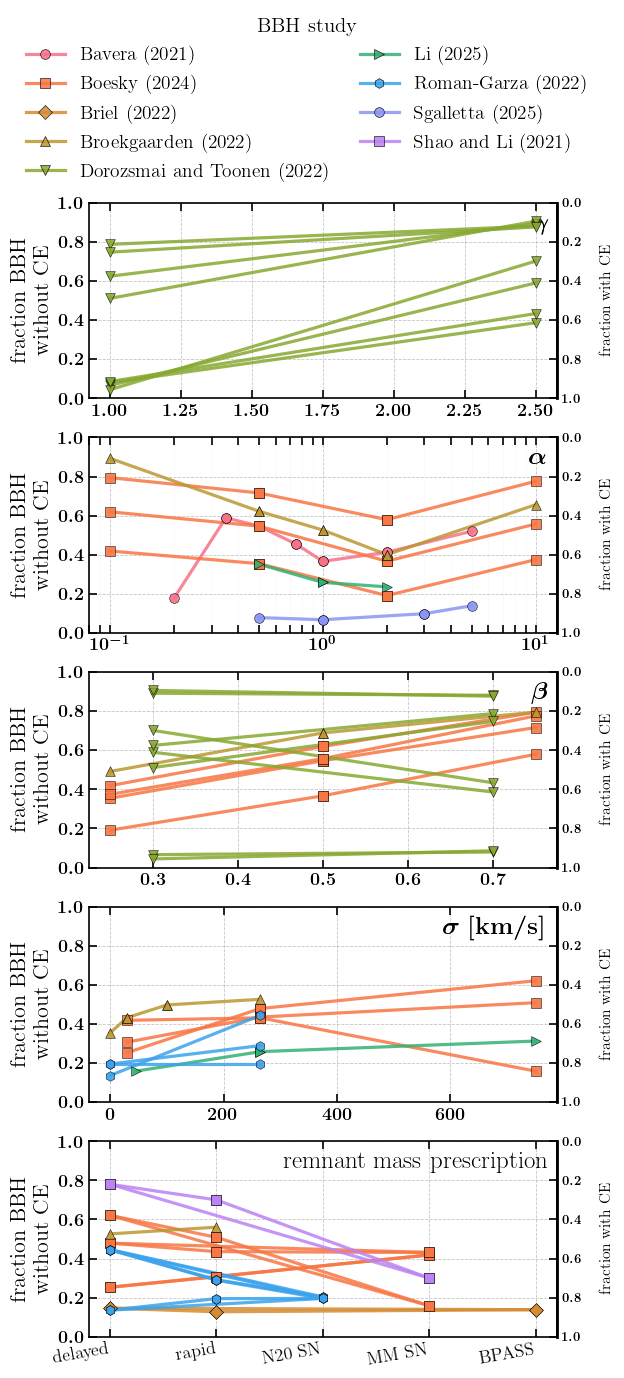

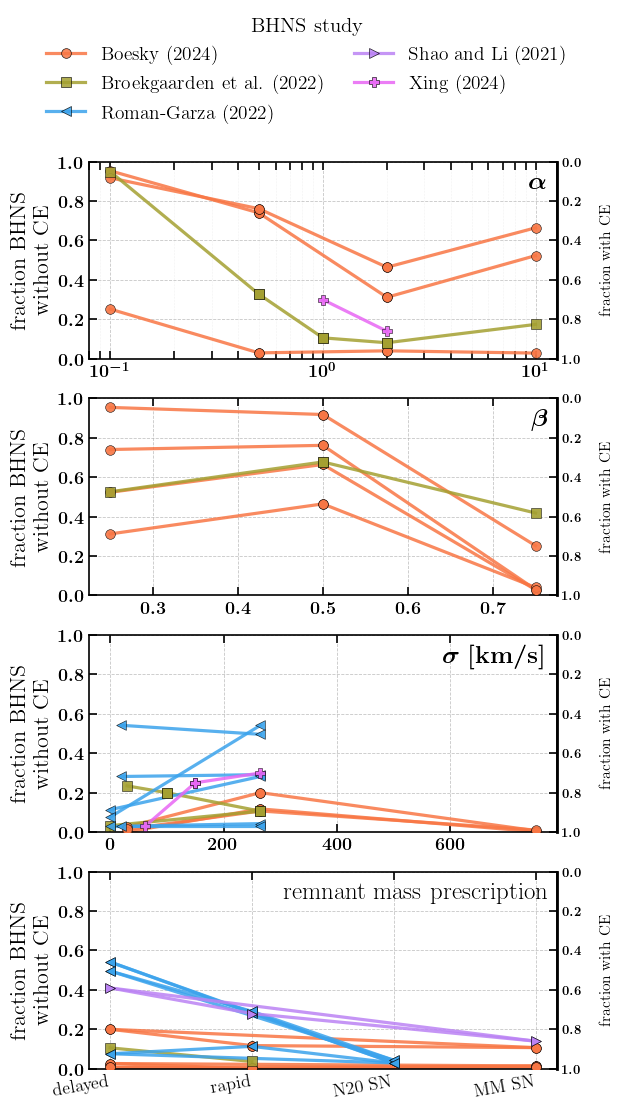

In [33]:

#### BBH ####
global_study_color_map = build_global_study_color_map(path_to_file, cmap_name="husl",)

path = path_to_file
DCOlabel = "BH-BH"



fig = plot_withoutCE_fraction_vs_parameters_static(
    path_to_file=path,
    parameters=[r"$\gamma$" ,r"$\alpha$", r"$\beta$",  r"$\sigma$", "remnant mass prescription"],
    DCOlabel=DCOlabel,
    ncols=1,
    palette_name="husl",
    parameter_map={
        r"$\gamma$":"CE gamma",
        r"$\beta$": "beta",
        r"$\alpha$": "alpha",
        "remnant mass prescription": "supernova",
        r"$\sigma$": "sigma",
    },
    category_orders={
        "remnant mass prescription": ["delayed", "rapid", "N20 SN", "MM SN"]
    },
    alpha_logx=True,
)

add_with_ce_axis(fig)
out = path_to_save_fig + f"Fig12_{DCOlabel}_withoutCE_fraction_vs_parameters.pdf"
fig.savefig(out,bbox_inches="tight")
plt.show()




#### BH - NS ####

path = path_to_file
DCOlabel = "BH-NS"

fig = plot_withoutCE_fraction_vs_parameters_static(
    path_to_file=path,
    parameters=[ r"$\alpha$", r"$\beta$",  r"$\sigma$", "remnant mass prescription"],
    DCOlabel=DCOlabel,
    ncols=1,
    palette_name="husl",
    parameter_map={
        r"$\beta$": "beta",
        r"$\alpha$": "alpha",
        "remnant mass prescription": "supernova",
        r"$\sigma$": "sigma",
    },
    category_orders={
        "remnant mass prescription": ["delayed", "rapid", "N20 SN", "MM SN"]
    },
    alpha_logx=True,
)

add_with_ce_axis(fig)

out = path_to_save_fig + f"Fig13_{DCOlabel}_withoutCE_fraction_vs_parameters.pdf"
fig.savefig(out, bbox_inches="tight")
plt.show()



## interactive version of the code 

In [34]:
## interactive version of the code 

import os
import math
from typing import Sequence, Optional, Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def plot_withoutCE_fraction_vs_parameters_interactive(
    path_to_file: str,
    parameters: Sequence[str],
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols: int = 1,
    panel_h_px: int = 260,
    panel_w_px: int = 900,
    marker_size: float = 8,
    line_width: float = 2.0,
    line_alpha: float = 0.9,
    palette_name: str = "husl",
    show_study_legend: bool = True,
    category_orders: Optional[Dict[str, List[str]]] = None,
    alpha_logx: bool = True,
    sigma_logx: bool = False,
    parameter_map: Optional[Dict[str, str]] = None,
    ylim: Tuple[float, float] = (0.0, 1.0),
    hover_spec_columns: Optional[List[str]] = None,
):
    """
    Interactive Plotly version of the without-CE fraction vs parameter figure.

    Each subplot is built from all relation rows that share the same value
    in the `using` column.

    Hover text includes:
      - study
      - from/to model names
      - from/to option values
      - y-values
      - selected assumptions from simulation_specs.csv for both endpoint models
    """

    # ---------------- helpers ----------------
    def normalize_text(s: Any) -> str:
        if s is None or (isinstance(s, float) and np.isnan(s)):
            return ""
        return str(s).strip()

    def normalize_key(s: Any) -> str:
        return normalize_text(s).lower()

    def normalize_option(o: Any) -> str:
        if o is None or (isinstance(o, float) and np.isnan(o)):
            return ""
        out = str(o).strip().replace("$", "").strip()

        if out.lower() == "n20":
            out = "N20 SN"
        elif out.lower() == "mm":
            out = "MM SN"

        return out

    def try_float(x: str) -> Optional[float]:
        try:
            return float(x)
        except Exception:
            return None

    def rgba_from_rgb(rgb, alpha=1.0):
        r, g, b = [int(round(255 * x)) for x in rgb]
        return f"rgba({r},{g},{b},{alpha})"

    def make_specs_html(model_name: str) -> str:
        if df_specs is None or model_name not in df_specs.index:
            return "No specs found"

        row = df_specs.loc[model_name]

        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        cols_to_use = hover_spec_columns
        if cols_to_use is None:
            cols_to_use = [c for c in df_specs.columns if not c.lower().startswith("unnamed")]

        bits = []
        for col in cols_to_use:
            if col not in row.index:
                continue
            val = row[col]
            if pd.isna(val):
                continue
            bits.append(f"<b>{col}</b>: {val}")

        return "<br>".join(bits) if bits else "No specs found"

    # ---------------- defaults ----------------
    if category_orders is None:
        category_orders = {}

    if parameter_map is None:
        parameter_map = {
            r"$\beta$": "beta",
            r"$\alpha$": "alpha",
            "remnant mass prescription": "supernova",
            r"$\sigma$": "sigma",
        }

    # ---------------- load relations ----------------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    rel_path = os.path.join(path_to_file, relation_file)
    df_rel = pd.read_csv(rel_path)

    required_rel_cols = {
        "legend",
        "from_modelname",
        "to_modelname",
        "from_option",
        "to_option",
        "using",
    }
    missing = required_rel_cols - set(df_rel.columns)
    if missing:
        raise ValueError(f"Relations file missing columns: {sorted(missing)}")

    df_rel = df_rel.copy()
    df_rel["using_norm"] = df_rel["using"].apply(normalize_key)

    # ---------------- load rates ----------------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    rates_path = os.path.join(path_to_file, rates_file)
    df_rates = pd.read_csv(rates_path)

    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")

    df_rates = df_rates.set_index("model")

    # ---------------- optional specs load ----------------
    specs_path = os.path.join(path_to_file, specs_file)
    if os.path.exists(specs_path):
        df_specs = pd.read_csv(specs_path)
        if "model" in df_specs.columns:
            df_specs = df_specs.set_index("model")
        else:
            df_specs = None
    else:
        df_specs = None

    # ---------------- selector ----------------
    def select_rows_for_parameter(df: pd.DataFrame, param_user: str) -> pd.DataFrame:
        using_value = parameter_map.get(param_user, param_user)
        using_norm = normalize_key(using_value)
        return df[df["using_norm"] == using_norm].copy()

    # ---------------- subplot geometry ----------------
    n_panels = len(parameters)
    ncols = max(1, int(ncols))
    nrows = int(math.ceil(n_panels / ncols))

    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        shared_yaxes=True,
        vertical_spacing=0.08,
        horizontal_spacing=0.08,
    )

    # ---------------- colors and markers by study ----------------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    palette = sns.color_palette(palette_name, max(1, len(legends_sorted)))
    color_map = {leg: rgba_from_rgb(palette[i % len(palette)], alpha=line_alpha) for i, leg in enumerate(legends_sorted)}

    marker_list = ["circle", "square", "diamond", "triangle-up", "triangle-down",
                   "triangle-left", "triangle-right", "cross", "x", "star", "hexagon"]
    marker_map = {leg: marker_list[i % len(marker_list)] for i, leg in enumerate(legends_sorted)}

    # ---------------- add traces ----------------
    legend_seen = set()

    for k, p_user in enumerate(parameters):
        row = (k // ncols) + 1
        col = (k % ncols) + 1

        dfp = select_rows_for_parameter(df_rel, str(p_user))

        if dfp.empty:
            continue

        # Gather options
        opt_from = [normalize_option(x) for x in dfp["from_option"].tolist()]
        opt_to = [normalize_option(x) for x in dfp["to_option"].tolist()]
        opts = [o for o in (opt_from + opt_to) if o != ""]

        floats = [try_float(o) for o in opts]
        is_numeric = (len(opts) > 0) and all(v is not None for v in floats)

        # Category ordering
        order = None
        if str(p_user) in category_orders:
            desired = [str(x) for x in category_orders[str(p_user)]]
            present = []
            for o in opts:
                if o not in present:
                    present.append(o)
            order = [x for x in desired if x in present] + [x for x in present if x not in desired]
        elif not is_numeric:
            seen = []
            for o in opts:
                if o not in seen:
                    seen.append(o)
            order = seen

        cat_to_x = {}
        x_to_cat = {}
        if not is_numeric:
            for i_cat, cat in enumerate(order):
                cat_to_x[cat] = i_cat
                x_to_cat[i_cat] = cat

        # Add one trace per relationship segment
        for leg in sorted(dfp["legend"].dropna().unique().tolist()):
            dfl = dfp[dfp["legend"] == leg]
            color_here = color_map.get(leg, "rgba(120,120,120,0.9)")
            marker_here = marker_map[leg]

            for _, rr in dfl.iterrows():
                m1 = rr["from_modelname"]
                m2 = rr["to_modelname"]

                if (m1 not in df_rates.index) or (m2 not in df_rates.index):
                    continue

                y1 = float(df_rates.loc[m1, "fraction without common envelope"])
                y2 = float(df_rates.loc[m2, "fraction without common envelope"])

                xo1 = normalize_option(rr["from_option"])
                xo2 = normalize_option(rr["to_option"])
                if xo1 == "" or xo2 == "":
                    continue

                if is_numeric:
                    x1 = float(xo1)
                    x2 = float(xo2)

                    using_value = parameter_map.get(str(p_user), str(p_user))
                    using_norm = normalize_key(using_value)

                    if alpha_logx and using_norm == "alpha" and (x1 <= 0 or x2 <= 0):
                        continue
                    if sigma_logx and using_norm == "sigma" and (x1 <= 0 or x2 <= 0):
                        continue
                else:
                    if xo1 not in cat_to_x or xo2 not in cat_to_x:
                        continue
                    x1 = cat_to_x[xo1]
                    x2 = cat_to_x[xo2]

                # In-panel label
                if r"\sigma" in str(p_user):
                    panel_label = r"$\sigma\ \mathrm{[km/s]}$"
                else:
                    panel_label = str(p_user)

                from_specs_html = make_specs_html(m1)
                to_specs_html = make_specs_html(m2)

                hover_text = (
                    f"<b>Study</b>: {leg}<br>"
                    f"<b>Parameter</b>: {panel_label}<br>"
                    f"<b>From model</b>: {m1}<br>"
                    f"<b>To model</b>: {m2}<br>"
                    f"<b>From option</b>: {xo1}<br>"
                    f"<b>To option</b>: {xo2}<br>"
                    f"<b>From without-CE fraction</b>: {y1:.4f}<br>"
                    f"<b>To without-CE fraction</b>: {y2:.4f}<br>"
                    f"<br><b>{m1} assumptions</b><br>{from_specs_html}"
                    f"<br><br><b>{m2} assumptions</b><br>{to_specs_html}"
                )

                show_legend_this_trace = show_study_legend and (leg not in legend_seen)

                fig.add_trace(
                    go.Scatter(
                        x=[x1, x2],
                        y=[y1, y2],
                        mode="lines+markers",
                        line=dict(color=color_here, width=line_width),
                        marker=dict(
                            symbol=marker_here,
                            size=marker_size,
                            color=color_here,
                            line=dict(width=0.5, color="rgba(0,0,0,0.5)")
                        ),
                        name=str(leg),
                        legendgroup=str(leg),
                        showlegend=show_legend_this_trace,
                        hovertemplate="%{text}<extra></extra>",
                        text=[hover_text, hover_text],
                    ),
                    row=row,
                    col=col,
                )

                if show_legend_this_trace:
                    legend_seen.add(leg)

        # Format x-axis
        axis_id = "" if (row == 1 and col == 1) else str((row - 1) * ncols + col)

        if is_numeric:
            using_value = parameter_map.get(str(p_user), str(p_user))
            using_norm = normalize_key(using_value)

            axis_type = "log" if (
                (alpha_logx and using_norm == "alpha") or
                (sigma_logx and using_norm == "sigma")
            ) else "linear"

            fig.update_xaxes(
                type=axis_type,
                showline=True,
                linewidth=1.2,
                linecolor="black",
                mirror=True,
                ticks="inside",
                ticklen=6,
                tickwidth=1.2,
                row=row,
                col=col,
            )
        else:
            tickvals = list(x_to_cat.keys())
            ticktext = list(x_to_cat.values())

            fig.update_xaxes(
                tickmode="array",
                tickvals=tickvals,
                ticktext=ticktext,
                showline=True,
                linewidth=1.2,
                linecolor="black",
                mirror=True,
                ticks="inside",
                ticklen=6,
                tickwidth=1.2,
                tickangle=10,
                row=row,
                col=col,
            )

        # Format y-axis
        fig.update_yaxes(
            range=list(ylim),
            showline=True,
            linewidth=1.2,
            linecolor="black",
            mirror=True,
            ticks="inside",
            ticklen=6,
            tickwidth=1.2,
            title_text="without CE fraction" if col == 1 else None,
            row=row,
            col=col,
        )

        # Add in-panel annotation
        if r"\sigma" in str(p_user):
            panel_text = r"$\sigma\ \mathrm{[km/s]}$"
        else:
            panel_text = str(p_user)

        fig.add_annotation(
            x=0.98,
            y=0.95,
            xref=f"x{axis_id} domain",
            yref=f"y{axis_id} domain",
            text=panel_text,
            showarrow=False,
            xanchor="right",
            yanchor="top",
            font=dict(size=18, color="black"),
            align="right",
            bgcolor="rgba(255,255,255,0.0)",
        )

    # ---------------- layout ----------------
    total_height = max(350, panel_h_px * nrows)
    total_width = panel_w_px if ncols == 1 else int(panel_w_px * ncols / 1.15)

    fig.update_layout(
        width=total_width,
        height=total_height,
        template="plotly_white",
        hovermode="closest",
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=70, r=30, t=110, b=60),
        legend=dict(
            title="Study",
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.08,
            yanchor="bottom",
            bgcolor="rgba(255,255,255,0.0)",
        ),
    )

    return fig



In [35]:
import plotly.io as pio
pio.renderers.default = "browser"


path = path_to_file
DCOlabel = "BH-BH"

fig_int = plot_withoutCE_fraction_vs_parameters_interactive(
    path_to_file=path,
    parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription", r"$\sigma$"],
    DCOlabel=DCOlabel,
    ncols=1,
    hover_spec_columns=["label_1", "label_2", "label_3", "label_4"],
    parameter_map={
        r"$\beta$": "beta",
        r"$\alpha$": "alpha",
        "remnant mass prescription": "supernova",
        r"$\sigma$": "sigma",
    },
    category_orders={
        "remnant mass prescription": ["BPASS", "N20 SN", "delayed", "rapid", "MM SN" ]
    },
    alpha_logx=True,
    sigma_logx=False,
    palette_name="husl",
)

fig_int.show()

out = path_interactive_fig + f"Fig12_{DCOlabel}_withoutCE_fraction_vs_parameters_interactive.html"
fig_int.write_html(
    out,
    include_plotlyjs="cdn"
)



In [36]:
import plotly.io as pio
pio.renderers.default = "browser"


path = path_to_file
DCOlabel = "BH-NS"

fig_int = plot_withoutCE_fraction_vs_parameters_interactive(
    path_to_file=path,
    parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription", r"$\sigma$"],
    DCOlabel=DCOlabel,
    ncols=1,
    hover_spec_columns=["label_1", "label_2", "label_3", "label_4"],
    parameter_map={
        r"$\beta$": "beta",
        r"$\alpha$": "alpha",
        "remnant mass prescription": "supernova",
        r"$\sigma$": "sigma",
    },
    category_orders={
        "remnant mass prescription": ["BPASS", "N20 SN", "delayed", "rapid", "MM SN" ]
    },
    alpha_logx=True,
    sigma_logx=False,
    palette_name="husl",
)

fig_int.show()

out = path_interactive_fig + f"Fig13_{DCOlabel}_withoutCE_fraction_vs_parameters_interactive.html"
fig_int.write_html(
    out,
    include_plotlyjs="cdn"
)



# Figure 11: which parameter causes the biggest change: BBH and BHNS

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_fc_change_by_parameter_family(
    path_to_file,
    DCOlabel="BH-BH",
    relation_file=None,
    fc_column="fraction without common envelope",
    used_column="using",
    legend_column="legend",
    from_column="from_modelname",
    to_column="to_modelname",
    cmap_name="husl",
    figsize=(9, 5),
    line_alpha=0.75,
    min_linewidth=3,
    max_linewidth=3.0,
    marker_size=40,
    sort_by="max_abs_change",  # "max_abs_change", "alphabetical"
    save_pdf=None,
    dpi=300,
    study_color_map=None  # add and use consistent color map for each simulation study
):
    """
    Plot the change in formation-channel contribution for each relationship.

    Each row in *_fcRelations.csv defines one relation: from_modelname -> to_modelname.
    For each relation, this computes

        Delta f = f(to_modelname) - f(from_modelname)

    where f is `fc_column`, e.g. "fraction without common envelope".

    The y-axis shows parameter/relationship families from the `used` column.
    Multiple studies using the same family are overplotted at the same y-position.
    """

    # --------------------------
    # Load files
    # --------------------------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"

    rel_path = os.path.join(path_to_file, relation_file)
    rates_path = os.path.join(path_to_file, f"{DCOlabel}_rates_review.csv")

    df_rel = pd.read_csv(rel_path)
    df_rates = pd.read_csv(rates_path).fillna(0.0).set_index("model")

    if fc_column not in df_rates.columns:
        raise ValueError(
            f"fc_column={fc_column!r} not found in rates file. "
            f"Available columns include:\n{list(df_rates.columns)}"
        )

    required_rel_cols = [used_column, legend_column, from_column, to_column]
    missing = [c for c in required_rel_cols if c not in df_rel.columns]
    if missing:
        raise ValueError(
            f"Missing required columns in relation file: {missing}\n"
            f"Available columns are:\n{list(df_rel.columns)}"
        )

    # --------------------------
    # Compute Delta f per relation
    # --------------------------
    rows = []

    for _, row in df_rel.iterrows():
        family = row[used_column]
        study = row[legend_column]
        m_from = row[from_column]
        m_to = row[to_column]

        if pd.isna(family) or pd.isna(study):
            continue

        if m_from not in df_rates.index or m_to not in df_rates.index:
            continue

        f_from = float(df_rates.loc[m_from, fc_column])
        f_to = float(df_rates.loc[m_to, fc_column])

        if not np.isfinite(f_from) or not np.isfinite(f_to):
            continue

        delta = f_to - f_from
        abs_delta = abs(delta)

        rows.append({
            "family": str(family).strip(),
            "study": str(study).strip(),
            "from_model": m_from,
            "to_model": m_to,
            "f_from": f_from,
            "f_to": f_to,
            "delta": delta,
            "abs_delta": abs_delta,
        })

    df_delta = pd.DataFrame(rows)
    min_change = 0.10  # 10%

    family_max_change = df_delta.groupby("family")["abs_delta"].max()

    families_to_keep = family_max_change[
        family_max_change >= min_change
    ].index

    df_delta = df_delta[
        df_delta["family"].isin(families_to_keep)
    ].copy()

    print(
        f"Kept {len(families_to_keep)} families with at least one "
        f"|Δf| >= {min_change:.0%}"
    )

    if len(df_delta) == 0:
        raise ValueError("No valid relations found after matching relation models to rates table.")

    # --------------------------
    # Sort families
    # --------------------------
    if sort_by == "max_abs_change":
        families = (
            df_delta.groupby("family")["abs_delta"]
            .max()
            .sort_values(ascending=True)
            .index
            .tolist()
        )
    elif sort_by == "alphabetical":
        families = sorted(df_delta["family"].unique())
    else:
        raise ValueError("sort_by must be 'max_abs_change' or 'alphabetical'.")

    y_map = {family: i for i, family in enumerate(families)}

    studies = sorted(df_delta["study"].unique())
    

    # Build per-family study offsets
    family_offset_map = {}
    for family in families:

        family_studies = (
            df_delta[df_delta["family"] == family]["study"]
            .unique()
            .tolist())

        n = len(family_studies)
        # No jitter if only one study
        if n == 1:
            offsets = [0.0]
        else:
            offsets = np.linspace(-0.22, 0.22, n)

        family_offset_map[family] = {
            study: offsets[i]
            for i, study in enumerate(family_studies)
        }
    
    ####
    if study_color_map is None:
        study_color_map = build_global_study_color_map(path_to_file, cmap_name=cmap_name)

    color_map = {
        study: study_color_map.get(normalize_study_label(study), "k")
        for study in studies
    }

    # Line styles help separate overlapping studies
    linestyles = ["-", "--", ":", "-."]
    linestyle_map = {
        study: linestyles[i % len(linestyles)]
        for i, study in enumerate(studies)
    }
    markers = ["o", "p", "D", "^", "v", "P", "X", "*", ">", "<"]
    marker_map = {
        study: markers[i % len(markers)]
        for i, study in enumerate(studies)
    }

    # Thicker lines for larger changes
    max_abs = df_delta["abs_delta"].max()
    if max_abs <= 0:
        max_abs = 1.0

    
    def linewidth_from_delta(abs_delta):
        return min_linewidth + (max_linewidth - min_linewidth) * (abs_delta / max_abs)

    # --------------------------
    # Plot
    # --------------------------
    fig, ax = plt.subplots(figsize=figsize)

    for _, row in df_delta.iterrows():
        y = (y_map[row["family"]]
            + family_offset_map[row["family"]][row["study"]])
        x0 = 0.0
        x1 = row["abs_delta"]
        study = row["study"]

        color = color_map[study]
        lw = linewidth_from_delta(row["abs_delta"])

        # Horizontal line from 0 to Delta f
        ax.plot(
            [x0, x1],
            [y, y],
            color=color,
            linestyle=linestyle_map[study],
            linewidth=lw,
            alpha=line_alpha,
            solid_capstyle="round",
            zorder=2,
        )

        # Marker at endpoint
        ax.scatter(
            x1,
            y,
            s=marker_size,
            color=color,
            marker=marker_map[study],
            edgecolor="k",
            linewidth=0.4,
            alpha=0.9,
            zorder=3,
        )

    # --------------------------
    # Axis formatting
    # --------------------------
    ax.set_yticks(range(len(families)))
    ax.set_yticklabels(families, fontsize=13)

    ax.set_xlabel(rf"$|\Delta$" +"fraction" + rf"$  |$",fontsize=16)
    
    pretty_labels = [
        label_map.get(fam.lower(), fam)  # fallback = original name
        for fam in families
    ]

    ax.set_yticklabels(pretty_labels, fontsize=13)
    
    # Fractions are usually 0--1; show percent-like ticks if desired
    ax.set_xlim(0, 1.)
    ax.set_xticks(np.linspace(0, 1, 11))

    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", alpha=0.15)

    ax.tick_params(axis="both", which="major", direction="in", labelsize=16)

    # Legend: one entry per study
    handles = [
        plt.Line2D(
            [], [],
            color=color_map[study],
            linestyle=linestyle_map[study],
            linewidth=4.5,
            marker=marker_map[study],
            markersize=np.sqrt(marker_size),
            markerfacecolor=color_map[study],
            markeredgecolor="k",
            markeredgewidth=0.5,
            label=study,
        )
        for study in studies
    ]
    
    dict_temp = {'BH-NS': 'BHNS', 'BH-BH': 'BBH', 'NS-NS': 'BNS'}
    ax.legend(
        handles=handles,
        title=r"$\textbf{%s} \ \textbf{Study}$"%dict_temp[DCOlabel],
        frameon=False,
        fontsize=12,
        title_fontsize=11,
        loc="lower right",
        bbox_to_anchor=(.99, .01),
        handlelength=3.5
    )

    fig.tight_layout()

    if save_pdf is not None:
        fig.savefig(save_pdf, bbox_inches="tight", dpi=dpi, transparent=True)
        print(f"Saved figure to: {save_pdf}")

    return fig, ax, df_delta


label_map = {
    "alpha": r"$\alpha_{\rm CE}$",
    "beta": r"$\beta$",
    "stability": r"$q_{\rm c}$",
    "casebb stability": r"Case BB stability",
    "sigma": r"$\sigma$",
    "kick velocity": r"$\sigma_{\rm kick}$",
    "remnant mass prescription": r"remnant mass prescription",
    "supernova": r"remnant mass " + "\n"+ r"prescription",
    "wind": r"stellar winds",
    "optimistic": r"optimistic CE",
    "gamma": r"$\gamma$",
    "ce gamma": r"$\gamma$",
    "$t_{eff}$": r"$T_{\rm eff}$",
    "eddington accretion": r"Eddington accretion",
    "priors": r"priors",
}



Kept 11 families with at least one |Δf| >= 10%
Saved figure to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/figures/extra_Fig_parameter_family_delta_withoutCE_BHBH.pdf
Kept 7 families with at least one |Δf| >= 10%
Saved figure to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/figures/extra_Fig_parameter_family_delta_withoutCE_BHNS.pdf


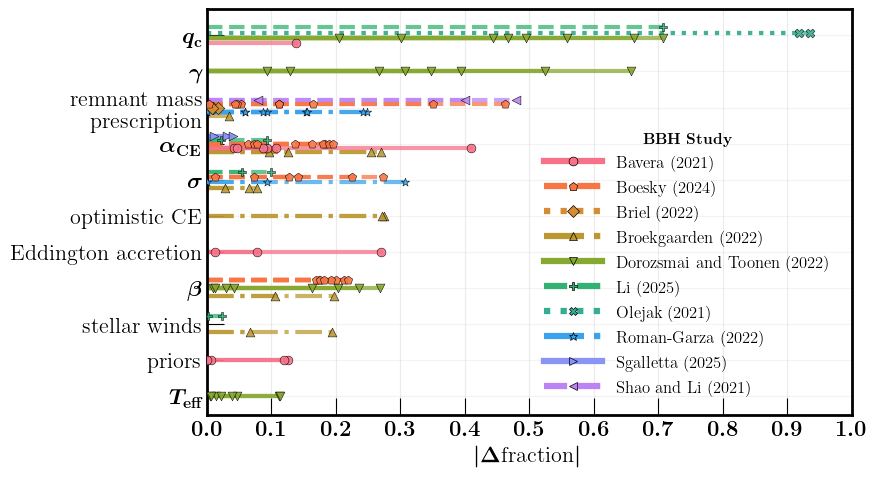

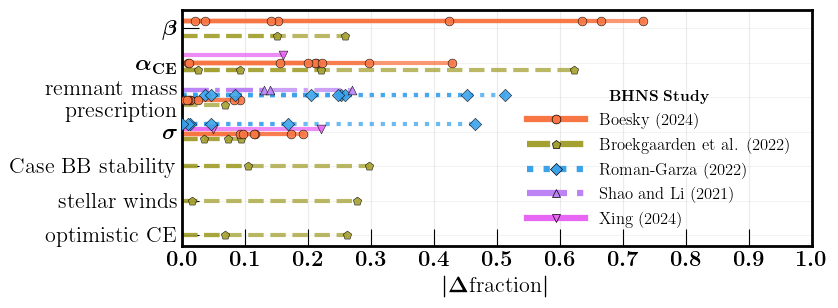

In [38]:
data_path = path_to_file

# set up global color map consistent colors for each study across code 
global_study_color_map = build_global_study_color_map(path_to_file, cmap_name="husl",)


fig, ax, df_delta = plot_fc_change_by_parameter_family(
    path_to_file=data_path,
    DCOlabel="BH-BH",
    fc_column="fraction without common envelope",
    save_pdf=path_to_save_fig + "extra_Fig_parameter_family_delta_withoutCE_BHBH.pdf",
    study_color_map=global_study_color_map
)


fig, ax, df_delta = plot_fc_change_by_parameter_family(
    path_to_file=data_path,
    DCOlabel="BH-NS",
    figsize=(8.6, 3.3),
    fc_column="fraction without common envelope",
    save_pdf=path_to_save_fig + "extra_Fig_parameter_family_delta_withoutCE_BHNS.pdf",
    study_color_map=global_study_color_map
)




